In [1]:
# Imports, Spark session, folders, and paths

import os
import pwd
import sys
from pathlib import Path
from random import randrange

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F


# ----------------------------------------------------------------------------
# Cluster context
# ----------------------------------------------------------------------------
username = pwd.getpwuid(os.getuid()).pw_name
hadoopFS = os.getenv("HADOOP_FS", None)
groupName = "H1"

print(os.getenv("SPARK_HOME"))
print(f"hadoopFSs={hadoopFS}")
print(f"username={username}")
print(f"group={groupName}")


# ----------------------------------------------------------------------------
# Spark session
# ----------------------------------------------------------------------------
spark = (
    SparkSession.builder
        .appName(username + "-final")
        .config("spark.ui.port", randrange(4050, 4450, 5))
        .config("spark.executorEnv.PYTHONPATH", ":".join(sys.path))
        .config("spark.jars",
                f"{hadoopFS}/data/com-490/jars/iceberg-spark-runtime-3.5_2.13-1.6.1.jar,"
                f"{hadoopFS}/data/com-490/jars/sedona-spark-shaded-3.5_2.13-1.7.1.jar,"
                f"{hadoopFS}/data/com-490/jars/geotools-wrapper-1.7.1-28.5.jar")
        .config("spark.sql.extensions",
                "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.sql.catalog.iceberg",
                "org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.iceberg.type", "hadoop")
        .config("spark.sql.catalog.iceberg.warehouse",
                f"{hadoopFS}/data/com-490/silver/")
        .config("spark.sql.catalog.spark_catalog",
                "org.apache.iceberg.spark.SparkSessionCatalog")
        .config("spark.sql.catalog.spark_catalog.type", "hadoop")
        .config("spark.sql.catalog.spark_catalog.warehouse",
                f"{hadoopFS}/user/{username}/assignment-3/warehouse")
        .config("spark.sql.warehouse.dir",
                f"{hadoopFS}/user/{username}/assignment-3/spark/warehouse")
        .config("spark.executor.memory", "6g")
        .config("spark.executor.cores", "4")
        .config("spark.executor.instances", "4")
        .master("yarn")
        .getOrCreate()
)


# ----------------------------------------------------------------------------
# Data root + figure output folder
# ----------------------------------------------------------------------------
BASE = "/user/groups/com-490/H1/final/v1"
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10


# ----------------------------------------------------------------------------
# Path candidates for each artifact (the read_first_available helper
# tries each path in order; lets the notebook survive minor path drift)
# ----------------------------------------------------------------------------
PATH_CANDIDATES = {
    "calib_pred": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_calib_predictions_full.parquet",
        f"{BASE}/calibration_model_data/eval_calib_predictions_full.parquet",
    ],
    "test_pred": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_test_predictions_full.parquet",
        f"{BASE}/calibration_model_data/eval_test_predictions_full.parquet",
    ],
    "test_quantiles": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_test_quantiles_backoff.parquet",
        f"{BASE}/calibration_model_data/eval_test_quantiles_backoff.parquet",
        f"{BASE}/test_quantiles_backoff.parquet",
    ],
    "global_quantiles": [
        f"{BASE}/calibration_model_data/calibration_artifacts/global_residual_quantiles.parquet",
        f"{BASE}/calibration_model_data/global_residual_quantiles.parquet",
    ],
    "feb_lookup": [
        f"{BASE}/route_demo_outputs/lookup/route_demo_lookup_february.parquet",
        f"{BASE}/route_demo_lookup_february.parquet",
    ],
}


def read_first_available(name):
    failures = []
    for path in PATH_CANDIDATES[name]:
        try:
            df = spark.read.parquet(path)
            df.limit(1).count()
            print(f"{name}: {path}")
            return df
        except Exception as exc:
            failures.append(f"{path}: {str(exc)[:100]}")
    raise FileNotFoundError(f"Could not read {name}:\n" + "\n".join(failures))


calib_pred_df       = read_first_available("calib_pred")
test_pred_df        = read_first_available("test_pred")
test_quantile_df    = read_first_available("test_quantiles")
global_quantiles_df = read_first_available("global_quantiles")
feb_lookup_df       = read_first_available("feb_lookup")

print("\nRows:")
print("calibration predictions:", calib_pred_df.count())
print("test predictions:       ", test_pred_df.count())
print("test quantiles:         ", test_quantile_df.count())
print("February lookup:        ", feb_lookup_df.count())
print("figure directory:       ", FIGURE_DIR)


/opt/spark
hadoopFSs=hdfs://iccluster061.iccluster.epfl.ch:9000
username=hsari
group=H1


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 08:58:11 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
26/05/25 08:58:20 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Attempted to request executors before the AM has registered!


calib_pred: /user/groups/com-490/H1/final/v1/calibration_model_data/evaluation_outputs/eval_calib_predictions_full.parquet


test_pred: /user/groups/com-490/H1/final/v1/calibration_model_data/evaluation_outputs/eval_test_predictions_full.parquet


test_quantiles: /user/groups/com-490/H1/final/v1/calibration_model_data/evaluation_outputs/eval_test_quantiles_backoff.parquet


...

feb_lookup: /user/groups/com-490/H1/final/v1/route_demo_outputs/lookup/route_demo_lookup_february.parquet

Rows:


calibration predictions: 7630465


test predictions:        2817641


test quantiles:          2817641


February lookup:         3071095
figure directory:        ../reports/figures


# Visualizations

In [ ]:
# Imports, Spark session, folders, and paths

import os
import pwd
import sys
from pathlib import Path
from random import randrange

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F
from pyspark.sql import functions as F
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


username = pwd.getpwuid(os.getuid()).pw_name
hadoopFS = os.getenv("HADOOP_FS", None)
groupName = "H1"

print(os.getenv("SPARK_HOME"))
print(f"hadoopFSs={hadoopFS}")
print(f"username={username}")
print(f"group={groupName}")


spark = (
    SparkSession.builder
        .appName(username + "-final")
        .config("spark.ui.port", randrange(4050, 4450, 5))
        .config("spark.executorEnv.PYTHONPATH", ":".join(sys.path))
        .config("spark.jars",
                f"{hadoopFS}/data/com-490/jars/iceberg-spark-runtime-3.5_2.13-1.6.1.jar,"
                f"{hadoopFS}/data/com-490/jars/sedona-spark-shaded-3.5_2.13-1.7.1.jar,"
                f"{hadoopFS}/data/com-490/jars/geotools-wrapper-1.7.1-28.5.jar")
        .config("spark.sql.extensions",
                "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.sql.catalog.iceberg",
                "org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.iceberg.type", "hadoop")
        .config("spark.sql.catalog.iceberg.warehouse",
                f"{hadoopFS}/data/com-490/silver/")
        .config("spark.sql.catalog.spark_catalog",
                "org.apache.iceberg.spark.SparkSessionCatalog")
        .config("spark.sql.catalog.spark_catalog.type", "hadoop")
        .config("spark.sql.catalog.spark_catalog.warehouse",
                f"{hadoopFS}/user/{username}/assignment-3/warehouse")
        .config("spark.sql.warehouse.dir",
                f"{hadoopFS}/user/{username}/assignment-3/spark/warehouse")
        .config("spark.executor.memory", "6g")
        .config("spark.executor.cores", "4")
        .config("spark.executor.instances", "4")
        .master("yarn")
        .getOrCreate()
)


BASE = "/user/groups/com-490/H1/final/v1"
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

PATH_CANDIDATES = {
    "calib_pred": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_calib_predictions_full.parquet",
        f"{BASE}/calibration_model_data/eval_calib_predictions_full.parquet",
    ],
    "test_pred": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_test_predictions_full.parquet",
        f"{BASE}/calibration_model_data/eval_test_predictions_full.parquet",
    ],
    "test_quantiles": [
        f"{BASE}/calibration_model_data/evaluation_outputs/eval_test_quantiles_backoff.parquet",
        f"{BASE}/calibration_model_data/eval_test_quantiles_backoff.parquet",
        f"{BASE}/test_quantiles_backoff.parquet",
    ],
    "global_quantiles": [
        f"{BASE}/calibration_model_data/calibration_artifacts/global_residual_quantiles.parquet",
        f"{BASE}/calibration_model_data/global_residual_quantiles.parquet",
    ],
    "feb_lookup": [
        f"{BASE}/route_demo_outputs/lookup/route_demo_lookup_february.parquet",
        f"{BASE}/route_demo_lookup_february.parquet",
    ],
}


def read_first_available(name):
    failures = []
    for path in PATH_CANDIDATES[name]:
        try:
            df = spark.read.parquet(path)
            df.limit(1).count()
            print(f"{name}: {path}")
            return df
        except Exception as exc:
            failures.append(f"{path}: {str(exc)[:100]}")
    raise FileNotFoundError(f"Could not read {name}:\n" + "\n".join(failures))


calib_pred_df       = read_first_available("calib_pred")
test_pred_df        = read_first_available("test_pred")
test_quantile_df    = read_first_available("test_quantiles")
global_quantiles_df = read_first_available("global_quantiles")
feb_lookup_df       = read_first_available("feb_lookup")

print("\nRows:")
print("calibration predictions:", calib_pred_df.count())
print("test predictions:       ", test_pred_df.count())
print("test quantiles:         ", test_quantile_df.count())
print("February lookup:        ", feb_lookup_df.count())
print("figure directory:       ", FIGURE_DIR)


train =  33,360,516  ( 76.2%)
calib =   7,630,465  ( 17.4%)
test  =   2,817,641  (  6.4%)
total =  43,808,622


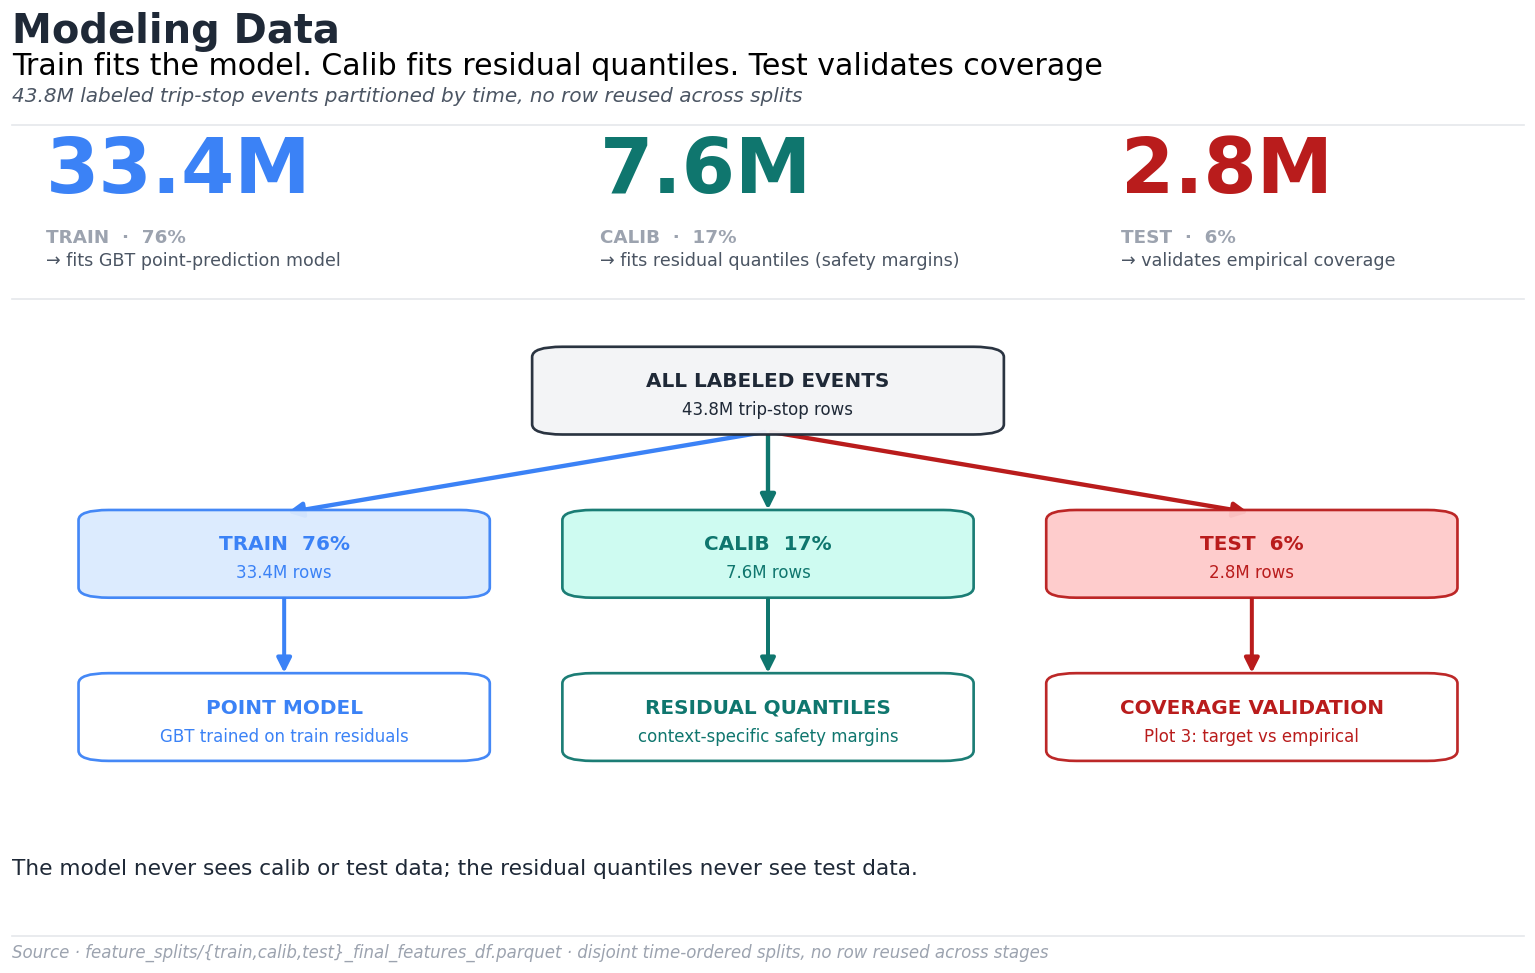

In [78]:
TRAIN_PATH = f"{BASE}/calibration_model_data/feature_splits/train_final_features_df.parquet
CALIB_PATH = f"{BASE}/calibration_model_data/feature_splits/calib_final_features_df.parquet"
TEST_PATH  = f"{BASE}/calibration_model_data/feature_splits/test_final_features_df.parquet"

n_train = spark.read.parquet(TRAIN_PATH).count()
n_calib = spark.read.parquet(CALIB_PATH).count()
n_test  = spark.read.parquet(TEST_PATH).count()
n_total = n_train + n_calib + n_test

pct_train = 100 * n_train / n_total
pct_calib = 100 * n_calib / n_total
pct_test  = 100 * n_test / n_total

print(f"train = {n_train:>11,}  ({pct_train:5.1f}%)")
print(f"calib = {n_calib:>11,}  ({pct_calib:5.1f}%)")
print(f"test  = {n_test:>11,}  ({pct_test:5.1f}%)")
print(f"total = {n_total:>11,}")

INK="#1F2937"; SOFT="#4B5563"; MUTED="#9CA3AF"
ACCENT="#0F766E"; WARN="#D97706"; HOT="#B91C1C"; RULE="#E5E7EB"
LIGHT_BG = "#F3F4F6"
TRAIN_C = "#3B82F6"
CALIB_C = "#0F766E"
TEST_C  = "#B91C1C"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":INK,
                     "axes.facecolor":"white","figure.facecolor":"white"})

def fmt_m(n):
    if n >= 1_000_000: return f"{n/1_000_000:.1f}M"
    if n >= 1_000: return f"{n/1_000:.0f}K"
    return f"{n:,}"

fig = plt.figure(figsize=(14, 8.5), facecolor="white")

fig.text(0.05, 0.952,
         "Modeling Data",
         fontsize=24, fontweight="bold", color=INK, ha="left", va="top")
fig.text(0.05, 0.913,
         "Train fits the model. Calib fits residual quantiles. Test validates coverage",
         fontsize=18, color="black", ha="left", va="top")
fig.text(0.05, 0.878,
         f"{fmt_m(n_total)} labeled trip-stop events partitioned by time, no row reused across splits",
         fontsize=12, color=SOFT, ha="left", va="top", style="italic")

fig.add_artist(plt.Line2D([0.05,0.95],[0.840,0.840],color=RULE,linewidth=1,transform=fig.transFigure))

fig.text(0.07, 0.795, fmt_m(n_train),
         fontsize=46, fontweight="bold", color=TRAIN_C, ha="left", va="center")
fig.text(0.07, 0.730, f"TRAIN  ·  {pct_train:.0f}%",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.07, 0.708, "→ fits GBT point-prediction model",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.text(0.40, 0.795, fmt_m(n_calib),
         fontsize=46, fontweight="bold", color=CALIB_C, ha="left", va="center")
fig.text(0.40, 0.730, f"CALIB  ·  {pct_calib:.0f}%",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.40, 0.708, "→ fits residual quantiles (safety margins)",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.text(0.71, 0.795, fmt_m(n_test),
         fontsize=46, fontweight="bold", color=TEST_C, ha="left", va="center")
fig.text(0.71, 0.730, f"TEST  ·  {pct_test:.0f}%",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.71, 0.708, "→ validates empirical coverage",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.add_artist(plt.Line2D([0.05,0.95],[0.670,0.670],color=RULE,linewidth=1,transform=fig.transFigure))

ax = fig.add_subplot(111)
ax.set_position([0.05, 0.16, 0.90, 0.50])
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)

def add_box(x, y, w, h, label, sublabel, fill, edge=None, text_color=INK):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.6,rounding_size=2",
        linewidth=1.6, edgecolor=edge or fill, facecolor=fill,
        alpha=0.95, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.62, label,
            ha="center", va="center", fontsize=12, fontweight="bold",
            color=text_color, zorder=3)
    ax.text(x + w/2, y + h*0.27, sublabel,
            ha="center", va="center", fontsize=10, color=text_color, zorder=3)

def add_arrow(x0, y0, x1, y1, color=MUTED, lw=2.2):
    arr = FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle="-|>", mutation_scale=18,
        color=color, linewidth=lw, zorder=1,
    )
    ax.add_patch(arr)

add_box(35, 76, 30, 16,
        f"ALL LABELED EVENTS",
        f"{fmt_m(n_total)} trip-stop rows",
        fill=LIGHT_BG, edge=INK, text_color=INK)

add_arrow(50, 76, 18, 60, color=TRAIN_C, lw=2.6)
add_arrow(50, 76, 50, 60, color=CALIB_C, lw=2.6)
add_arrow(50, 76, 82, 60, color=TEST_C, lw=2.6)

add_box(5, 44, 26, 16,
        f"TRAIN  {pct_train:.0f}%",
        f"{fmt_m(n_train)} rows",
        fill="#DBEAFE", edge=TRAIN_C, text_color=TRAIN_C)
add_box(37, 44, 26, 16,
        f"CALIB  {pct_calib:.0f}%",
        f"{fmt_m(n_calib)} rows",
        fill="#CCFBF1", edge=CALIB_C, text_color=CALIB_C)
add_box(69, 44, 26, 16,
        f"TEST  {pct_test:.0f}%",
        f"{fmt_m(n_test)} rows",
        fill="#FECACA", edge=TEST_C, text_color=TEST_C)

add_arrow(18, 44, 18, 28, color=TRAIN_C, lw=2.4)
add_arrow(50, 44, 50, 28, color=CALIB_C, lw=2.4)
add_arrow(82, 44, 82, 28, color=TEST_C, lw=2.4)

add_box(5, 12, 26, 16,
        "POINT MODEL",
        "GBT trained on train residuals",
        fill="white", edge=TRAIN_C, text_color=TRAIN_C)
add_box(37, 12, 26, 16,
        "RESIDUAL QUANTILES",
        "context-specific safety margins",
        fill="white", edge=CALIB_C, text_color=CALIB_C)
add_box(69, 12, 26, 16,
        "COVERAGE VALIDATION",
        "Plot 3: target vs empirical",
        fill="white", edge=TEST_C, text_color=TEST_C)

fig.text(0.05, 0.122,
         "The model never sees calib or test data; the residual quantiles never see test data.\n",
         fontsize=13, color=INK, ha="left", va="top")

fig.add_artist(plt.Line2D([0.05,0.95],[0.045,0.045],color=RULE,linewidth=1,transform=fig.transFigure))
fig.text(0.05, 0.025,
         "Source · feature_splits/{train,calib,test}_final_features_df.parquet · disjoint time-ordered splits, "
         "no row reused across stages",
         fontsize=10, color=MUTED, ha="left", style="italic")

fig.savefig(FIGURE_DIR / "01_deck_method_architecture.png",
            dpi=200, bbox_inches=None, facecolor="white")
plt.show()

In [ ]:
# Show how calibrated quantiles are grouped — the L6 → global backoff config

CONFIG_PATH = (
    f"{BASE}/calibration_model_data/calibration_artifacts/"
    "calibration_config.parquet"
)
config_df = spark.read.parquet(CONFIG_PATH)

print("=" * 65)
print("Raw calibration_config.parquet contents:")
print("=" * 65)
config_df.show(truncate=False)

# Parse into a dictionary: level -> [group columns]
config_rows = config_df.collect()
GROUP_LEVELS = {
    row["level_name"]: row["group_cols_csv"].split(",")
    for row in config_rows
}

# Print the grouping columns per level (richest to broadest)
LEVEL_ORDER = [
    "L6_line_specific",
    "L5_ultra_rich",
    "L4_rich",
    "L3_operational",
    "L2_context",
    "L1_core",
    "L0_simple",
]

print("\n" + "=" * 65)
print("Calibration grouping per level (rich → simple):")
print("=" * 65)
for lvl in LEVEL_ORDER:
    cols = GROUP_LEVELS.get(lvl)
    if cols is None:
        print(f"  {lvl:24s} (not in config)")
        continue
    print(f"\n  {lvl}")
    for c in cols:
        print(f"      · {c}")
print(f"\n  global  (fallback for any row whose richer group has too few calib obs)")

# Read MIN_GROUP_ROWS — the threshold for trusting a group
try:
    min_rows = int(config_df.select("min_group_rows").first()["min_group_rows"])
    print(f"\nMIN_GROUP_ROWS = {min_rows:,}")
    print("  → if a context group has fewer than this many calibration observations,")
    print("    its residual quantile is considered unstable and the pipeline backs off.")
except Exception as e:
    print(f"\n(MIN_GROUP_ROWS column not found in config: {e})")

# What level did the demo trip end up using?
print("\n" + "=" * 65)
print("Backoff level chosen for the Section-2 example trip:")
print("=" * 65)
try:
    level_used = trip_row.get("chosen_calibration_level_q90", "(column missing)")
    print(f"  trip_id = {TRIP_ID}")
    print(f"  bpuic   = {BPUIC}  ({STOP_NAME if 'STOP_NAME' in dir() else ''})")
    print(f"  arrival = {ARRIVAL}")
    print(f"  chosen_calibration_level_q90 = {level_used}")
    if level_used in GROUP_LEVELS:
        print(f"\n  → which means the q90 for this trip was computed by grouping on:")
        for c in GROUP_LEVELS[level_used]:
            print(f"      · {c}")
    elif level_used == "global":
        print("  → the global fallback was used (no context-specific group had enough data)")
except NameError:
    print("  (trip_row not available — run the Section 2 dashboard cell first)")


OVER  :  49.2%  · median |error| = 92s · p90 = 229s
NEAR  :  23.7%  · |residual| ≤ 30s
UNDER :  27.1%  · median size  = 103s · p90 = 380s


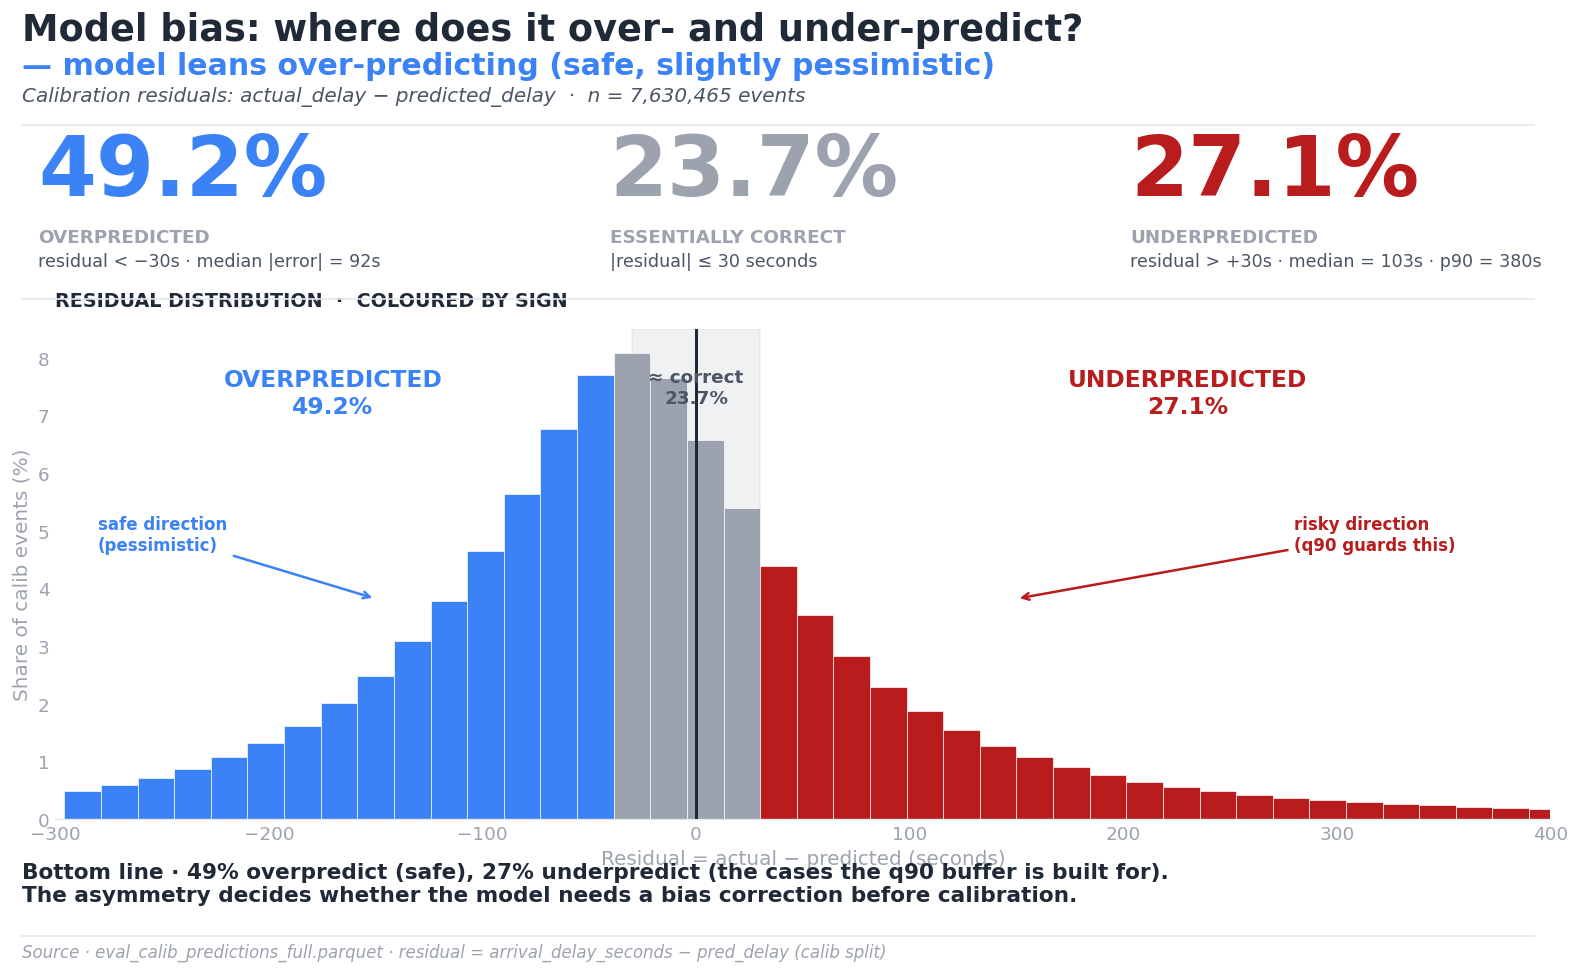

In [33]:
NEAR_THRESHOLD = 30  # seconds; "essentially correct" tolerance

# --- 1) Spark aggregations: 3-way exclusive partition ---
sign_stats = calib_error_df.agg(
    F.avg((F.col("residual") < -NEAR_THRESHOLD).cast("double")).alias("pct_over"),
    F.avg((F.abs(F.col("residual")) <= NEAR_THRESHOLD).cast("double")).alias("pct_near"),
    F.avg((F.col("residual") > NEAR_THRESHOLD).cast("double")).alias("pct_under"),
).first().asDict()

over_stats = (
    calib_error_df.filter(F.col("residual") < -NEAR_THRESHOLD)
    .agg(
        F.expr("percentile_approx(abs(residual), 0.5)").alias("median_size"),
        F.expr("percentile_approx(abs(residual), 0.9)").alias("p90_size"),
    ).first().asDict()
)
under_stats = (
    calib_error_df.filter(F.col("residual") > NEAR_THRESHOLD)
    .agg(
        F.expr("percentile_approx(residual, 0.5)").alias("median_size"),
        F.expr("percentile_approx(residual, 0.9)").alias("p90_size"),
    ).first().asDict()
)

pct_over  = 100 * float(sign_stats["pct_over"])
pct_near  = 100 * float(sign_stats["pct_near"])
pct_under = 100 * float(sign_stats["pct_under"])
over_median  = float(over_stats["median_size"])
over_p90     = float(over_stats["p90_size"])
under_median = float(under_stats["median_size"])
under_p90    = float(under_stats["p90_size"])

print(f"OVER  : {pct_over:5.1f}%  · median |error| = {over_median:.0f}s · p90 = {over_p90:.0f}s")
print(f"NEAR  : {pct_near:5.1f}%  · |residual| ≤ {NEAR_THRESHOLD}s")
print(f"UNDER : {pct_under:5.1f}%  · median size  = {under_median:.0f}s · p90 = {under_p90:.0f}s")

# --- 2) Dashboard render ---
INK="#1F2937"; SOFT="#4B5563"; MUTED="#9CA3AF"
ACCENT="#0F766E"; WARN="#D97706"; HOT="#B91C1C"; RULE="#E5E7EB"
OVER_C  = "#3B82F6"
UNDER_C = "#B91C1C"
NEAR_C  = "#9CA3AF"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":INK,
                     "axes.facecolor":"white","figure.facecolor":"white"})

if pct_under > pct_over + 2:
    verdict = "model leans under-predicting (risky for routing)"
    verdict_color = HOT
elif pct_over > pct_under + 2:
    verdict = "model leans over-predicting (safe, slightly pessimistic)"
    verdict_color = OVER_C
else:
    verdict = "model is roughly balanced"
    verdict_color = ACCENT

fig = plt.figure(figsize=(14, 8.5), facecolor="white")

fig.text(0.05, 0.952, "Model bias: where does it over- and under-predict?",
         fontsize=22, fontweight="bold", color=INK, ha="left", va="top")
fig.text(0.05, 0.913, f"— {verdict}",
         fontsize=18, fontweight="bold", color=verdict_color, ha="left", va="top")
fig.text(0.05, 0.878,
         f"Calibration residuals: actual_delay − predicted_delay  ·  n = {n_calib:,} events",
         fontsize=12, color=SOFT, ha="left", va="top", style="italic")

fig.add_artist(plt.Line2D([0.05,0.95],[0.840,0.840],color=RULE,linewidth=1,transform=fig.transFigure))

# KPI tiles
fig.text(0.06, 0.795, f"{pct_over:.1f}%",
         fontsize=50, fontweight="bold", color=OVER_C, ha="left", va="center")
fig.text(0.06, 0.730, "OVERPREDICTED",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.06, 0.707, f"residual < −{NEAR_THRESHOLD}s · median |error| = {over_median:.0f}s",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.text(0.40, 0.795, f"{pct_near:.1f}%",
         fontsize=50, fontweight="bold", color=NEAR_C, ha="left", va="center")
fig.text(0.40, 0.730, "ESSENTIALLY CORRECT",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.40, 0.707, f"|residual| ≤ {NEAR_THRESHOLD} seconds",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.text(0.71, 0.795, f"{pct_under:.1f}%",
         fontsize=50, fontweight="bold", color=UNDER_C, ha="left", va="center")
fig.text(0.71, 0.730, "UNDERPREDICTED",
         fontsize=11, color=MUTED, ha="left", va="center", fontweight="bold")
fig.text(0.71, 0.707, f"residual > +{NEAR_THRESHOLD}s · median = {under_median:.0f}s · p90 = {under_p90:.0f}s",
         fontsize=10.5, color=SOFT, ha="left", va="center")

fig.add_artist(plt.Line2D([0.05,0.95],[0.670,0.670],color=RULE,linewidth=1,transform=fig.transFigure))

gs = fig.add_gridspec(1, 1, left=0.07, right=0.96, bottom=0.16, top=0.640)
ax = fig.add_subplot(gs[0, 0])
ax.set_title("RESIDUAL DISTRIBUTION  ·  COLOURED BY SIGN", loc="left",
             fontsize=11.5, fontweight="bold", color=INK, pad=14)

HIST_LO, HIST_HI = max(PLOT_MIN, -300), min(PLOT_MAX, 400)
disp = histogram_pdf[histogram_pdf["bin_center"].between(HIST_LO, HIST_HI)].copy()

bar_colors = [OVER_C if c < -NEAR_THRESHOLD else
              (UNDER_C if c > NEAR_THRESHOLD else NEAR_C)
              for c in disp["bin_center"]]

ax.bar(disp["bin_center"], disp["pct_all"],
       width=BIN_WIDTH, color=bar_colors, edgecolor="white", linewidth=0.4, zorder=2)
ax.axvspan(-NEAR_THRESHOLD, NEAR_THRESHOLD, color=NEAR_C, alpha=0.15, zorder=1)
ax.axvline(0, color=INK, linewidth=1.8, zorder=3)

ymax = ax.get_ylim()[1]
ax.text(-170, ymax*0.92, f"OVERPREDICTED\n{pct_over:.1f}%",
        ha="center", va="top", fontsize=14, fontweight="bold", color=OVER_C)
ax.text(0, ymax*0.92, f"≈ correct\n{pct_near:.1f}%",
        ha="center", va="top", fontsize=11, fontweight="bold", color=SOFT)
ax.text(230, ymax*0.92, f"UNDERPREDICTED\n{pct_under:.1f}%",
        ha="center", va="top", fontsize=14, fontweight="bold", color=UNDER_C)

ax.annotate("safe direction\n(pessimistic)", xy=(-150, ymax*0.45),
            xytext=(-280, ymax*0.55),
            fontsize=10, color=OVER_C, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=OVER_C, linewidth=1.5))
ax.annotate("risky direction\n(q90 guards this)", xy=(150, ymax*0.45),
            xytext=(280, ymax*0.55),
            fontsize=10, color=UNDER_C, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=UNDER_C, linewidth=1.5))

ax.set_xlim(HIST_LO, HIST_HI)
ax.set_xlabel("Residual = actual − predicted (seconds)", color=MUTED, fontsize=12)
ax.set_ylabel("Share of calib events (%)", color=MUTED, fontsize=12)
ax.tick_params(axis="both", colors=MUTED, length=0, labelsize=11)
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color(RULE)

fig.text(0.05, 0.118,
         f"Bottom line · {pct_over:.0f}% overpredict (safe), {pct_under:.0f}% underpredict "
         f"(the cases the q90 buffer is built for).\n"
         f"The asymmetry decides whether the model needs a bias correction before calibration.",
         fontsize=13, fontweight="bold", color=INK, ha="left", va="top")

fig.add_artist(plt.Line2D([0.05,0.95],[0.045,0.045],color=RULE,linewidth=1,transform=fig.transFigure))
fig.text(0.05, 0.025,
         "Source · eval_calib_predictions_full.parquet · residual = arrival_delay_seconds − pred_delay (calib split)",
         fontsize=10, color=MUTED, ha="left", style="italic")

fig.savefig(FIGURE_DIR / "appendix_over_under_distribution.png",
            dpi=200, bbox_inches=None, facecolor="white")
plt.show()


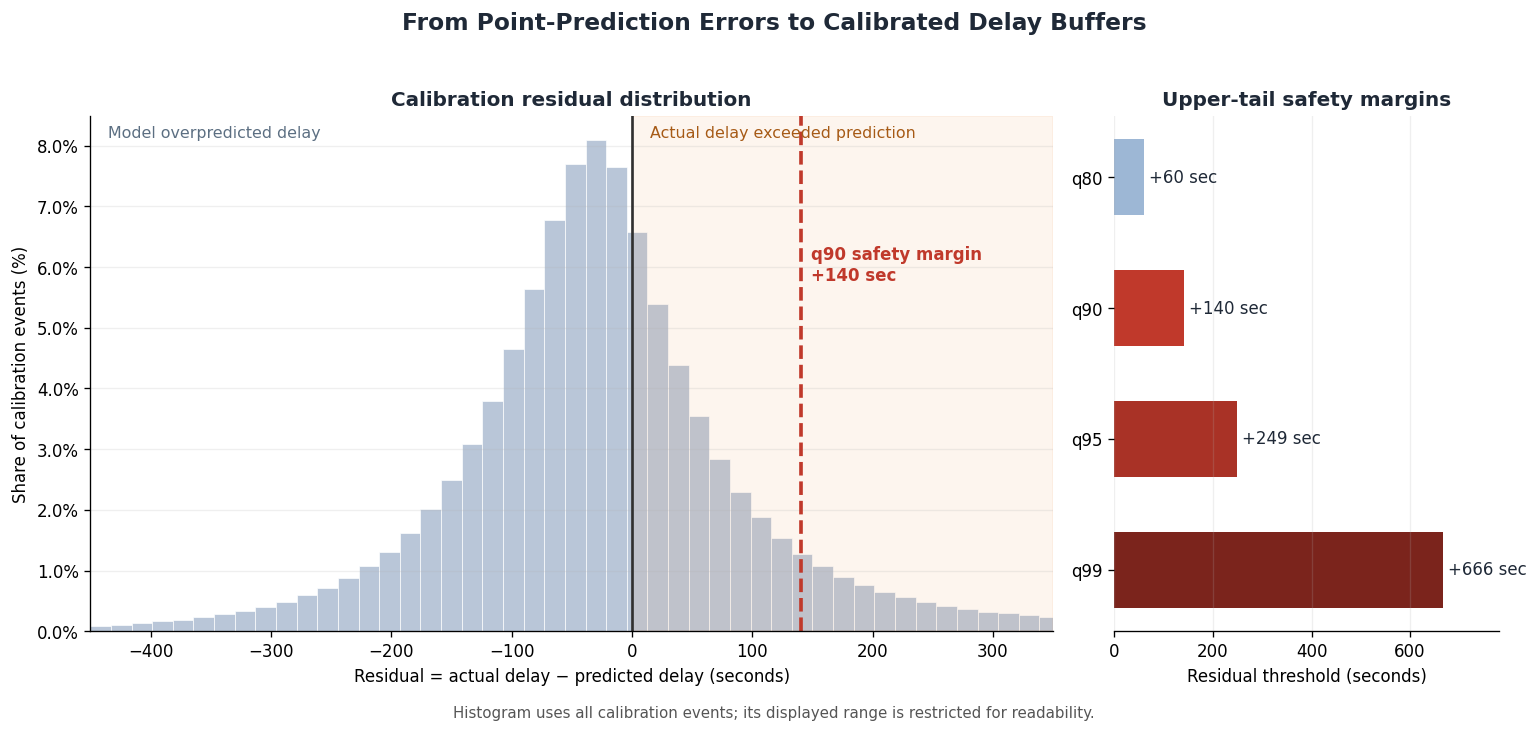

In [34]:
HIST_X_MIN, HIST_X_MAX = PLOT_MIN, 350
hist_display_pdf = histogram_pdf[
    histogram_pdf["bin_center"].between(HIST_X_MIN, HIST_X_MAX)
]

fig, (ax_hist, ax_margin) = plt.subplots(
    1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [2.5, 1]}
)

ax_hist.bar(hist_display_pdf["bin_center"], hist_display_pdf["pct_all"],
            width=BIN_WIDTH, color="#B9C6D8", edgecolor="white", linewidth=0.4)
ax_hist.axvspan(0, HIST_X_MAX, color="#F4A261", alpha=0.10)
ax_hist.axvline(0, color="#303030", linewidth=1.6)
ax_hist.axvline(q90, color="#C0392B", linestyle="--", linewidth=2.2)

ymax = ax_hist.get_ylim()[1]
ax_hist.text(HIST_X_MIN + 15, ymax * 0.98, "Model overpredicted delay",
             ha="left", va="top", fontsize=9.5, color="#5C6F82")
ax_hist.text(15, ymax * 0.98, "Actual delay exceeded prediction",
             ha="left", va="top", fontsize=9.5, color="#A65A16")
ax_hist.text(q90 + 8, ymax * 0.68, f"q90 safety margin\n+{q90:.0f} sec",
             color="#C0392B", fontweight="bold")

ax_hist.set_title("Calibration residual distribution", fontweight="bold")
ax_hist.set_xlabel("Residual = actual delay − predicted delay (seconds)")
ax_hist.set_ylabel("Share of calibration events (%)")
ax_hist.set_xlim(HIST_X_MIN, HIST_X_MAX)
ax_hist.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax_hist.grid(axis="y", alpha=0.20)
ax_hist.spines[["top", "right"]].set_visible(False)

m_names = ["q80", "q90", "q95", "q99"]
m_values = [q80, q90, q95, q99]
y = np.arange(len(m_names))
ax_margin.barh(y, m_values, color=["#9DB7D5", "#C0392B", "#A93226", "#7B241C"], height=0.58)
ax_margin.set_yticks(y)
ax_margin.set_yticklabels(m_names)
ax_margin.invert_yaxis()
for pos, val in zip(y, m_values):
    ax_margin.text(val + 10, pos, f"+{val:.0f} sec", va="center")
ax_margin.set_title("Upper-tail safety margins", fontweight="bold")
ax_margin.set_xlabel("Residual threshold (seconds)")
ax_margin.set_xlim(0, q99 + 115)
ax_margin.grid(axis="x", alpha=0.20)
ax_margin.spines[["top", "right", "left"]].set_visible(False)

fig.suptitle("From Point-Prediction Errors to Calibrated Delay Buffers",
             fontsize=14, fontweight="bold", y=1.03)
fig.text(0.5, -0.02,
         "Histogram uses all calibration events; its displayed range is restricted for readability.",
         ha="center", fontsize=9, color="#555555")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_calibration_residual_safety_margins.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1012852/3902755317.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.965])


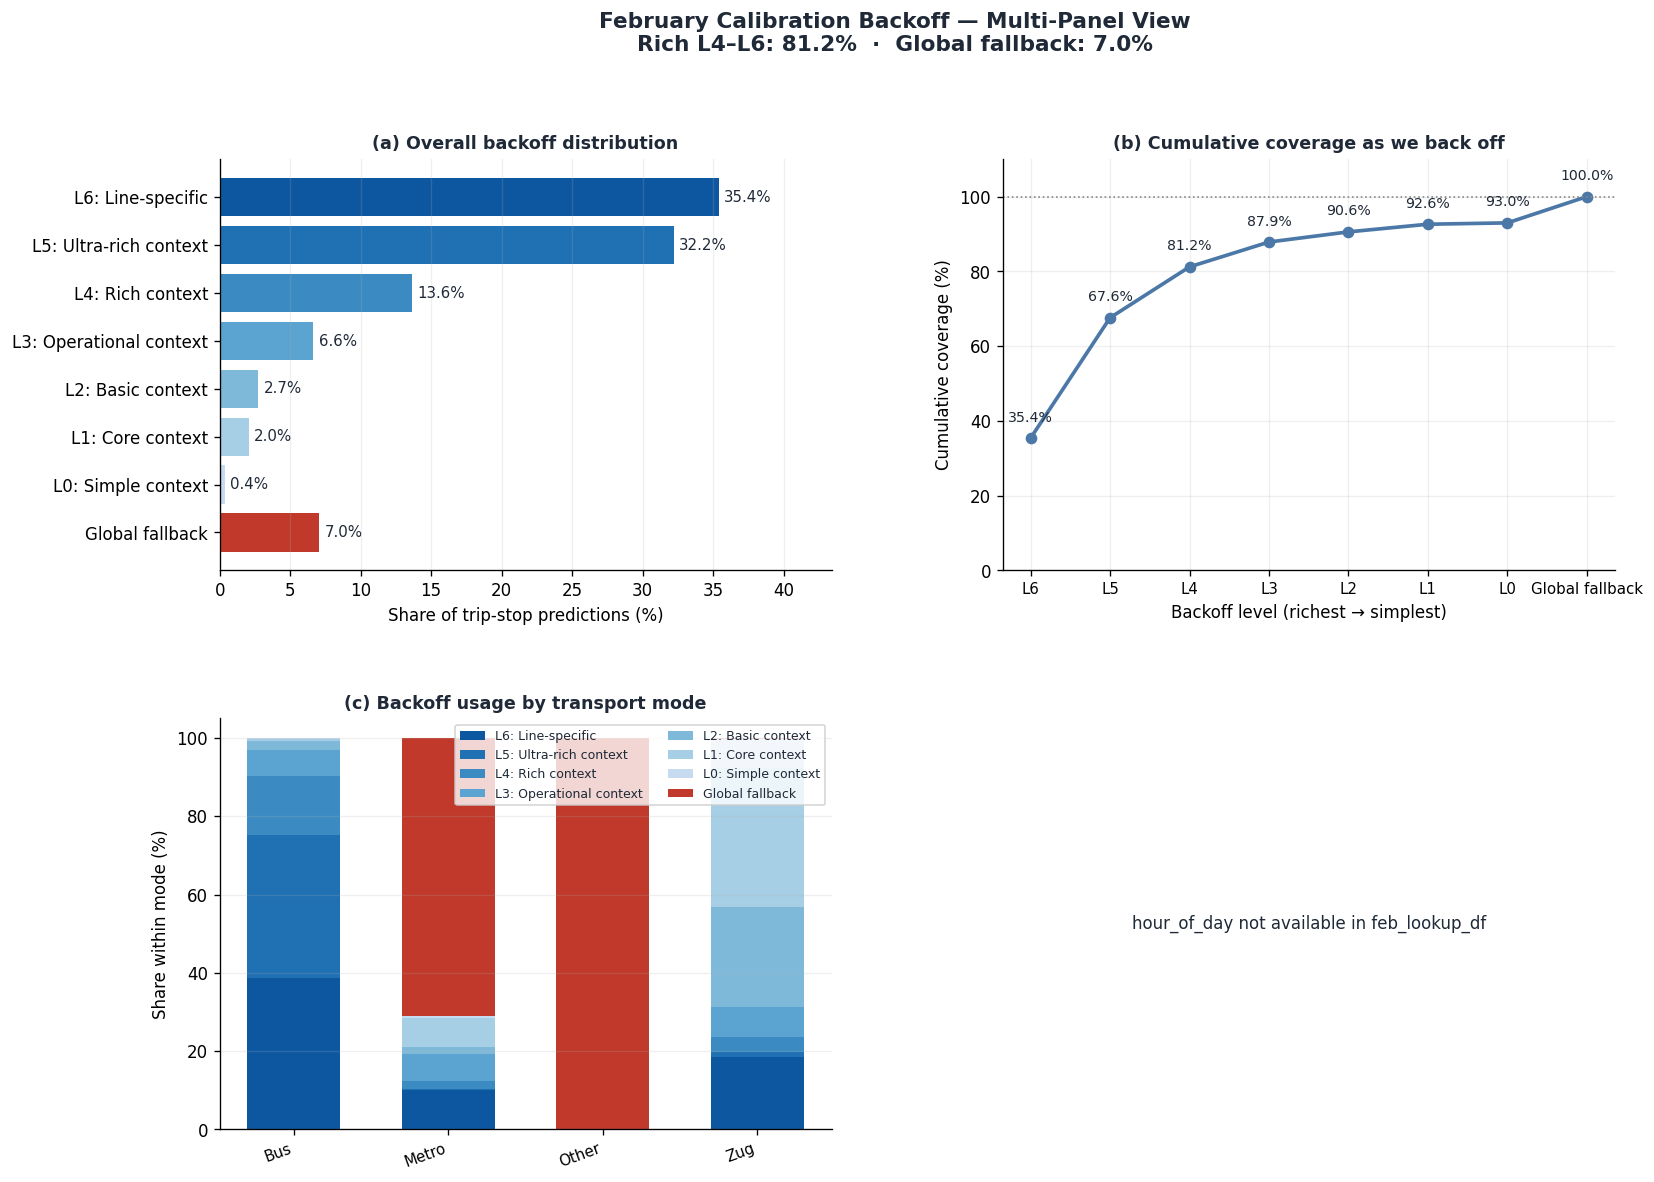

In [39]:
# Plot 4 (multi-panel) — February calibration backoff distribution

import matplotlib as mpl

# Blue ramp for backoff levels (richest darkest), red for global fallback
n_levels = len(LEVEL_ORDER) - 1  # excludes "global"
ramp = mpl.colormaps.get_cmap("Blues")(np.linspace(0.85, 0.25, n_levels))
level_colors = {lvl: ramp[i] for i, lvl in enumerate(LEVEL_ORDER[:-1])}
level_colors["global"] = "#C0392B"

# Optional breakdowns (require Spark)
transport_breakdown = None
hour_breakdown = None

if "transport_clean" in feb_lookup_df.columns:
    transport_breakdown = (
        feb_lookup_df.groupBy("transport_clean", LEVEL_COL)
        .agg(F.count("*").alias("n"))
        .toPandas()
    )
    transport_totals = (
        transport_breakdown.groupby("transport_clean")["n"].sum().to_dict()
    )
    transport_breakdown["pct"] = transport_breakdown.apply(
        lambda r: 100 * r["n"] / transport_totals[r["transport_clean"]],
        axis=1
    )

if "hour_of_day" in feb_lookup_df.columns:
    hour_df = feb_lookup_df.withColumn(
        "hour_bucket",
        F.when((F.col("hour_of_day") >= 7) & (F.col("hour_of_day") < 10), "morning_peak")
         .when((F.col("hour_of_day") >= 16) & (F.col("hour_of_day") < 19), "evening_peak")
         .when((F.col("hour_of_day") >= 23) | (F.col("hour_of_day") < 5), "late_night")
         .otherwise("offpeak")
    )
    hour_breakdown = (
        hour_df.groupBy("hour_bucket", LEVEL_COL)
        .agg(F.count("*").alias("n"))
        .toPandas()
    )
    hour_totals = hour_breakdown.groupby("hour_bucket")["n"].sum().to_dict()
    hour_breakdown["pct"] = hour_breakdown.apply(
        lambda r: 100 * r["n"] / hour_totals[r["hour_bucket"]], axis=1
    )

fig = plt.figure(figsize=(15, 10.5))
gs = fig.add_gridspec(2, 2, hspace=0.36, wspace=0.28)

# (a) Overall
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(backoff_pdf["label"], backoff_pdf["pct"],
         color=[level_colors[l] for l in backoff_pdf[LEVEL_COL]])
ax1.invert_yaxis()
for i, r in backoff_pdf.iterrows():
    ax1.text(r["pct"] + 0.4, i, f"{r['pct']:.1f}%", va="center", fontsize=9)
ax1.set_xlim(0, backoff_pdf["pct"].max() + 8)
ax1.set_xlabel("Share of trip-stop predictions (%)")
ax1.set_title("(a) Overall backoff distribution",
              fontweight="bold", fontsize=10.5)
ax1.grid(axis="x", alpha=0.20)
ax1.spines[["top", "right"]].set_visible(False)

# (b) Cumulative coverage richest -> simplest
ax2 = fig.add_subplot(gs[0, 1])
cum_pdf = backoff_pdf.copy()
cum_pdf["cum_pct"] = cum_pdf["pct"].cumsum()
ax2.plot(np.arange(len(cum_pdf)), cum_pdf["cum_pct"], marker="o",
         color="#4C78A8", linewidth=2.2)
for i, r in cum_pdf.iterrows():
    ax2.annotate(f"{r['cum_pct']:.1f}%", (i, r["cum_pct"]),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=8.5)
ax2.set_xticks(np.arange(len(cum_pdf)))
ax2.set_xticklabels([l.split(":")[0] for l in cum_pdf["label"]],
                    rotation=0, fontsize=9)
ax2.axhline(100, color="#888", linestyle=":", linewidth=1)
ax2.set_ylabel("Cumulative coverage (%)")
ax2.set_xlabel("Backoff level (richest → simplest)")
ax2.set_title("(b) Cumulative coverage as we back off",
              fontweight="bold", fontsize=10.5)
ax2.set_ylim(0, 110)
ax2.grid(alpha=0.20)
ax2.spines[["top", "right"]].set_visible(False)

# (c) Stacked by transport mode
ax3 = fig.add_subplot(gs[1, 0])
if transport_breakdown is not None and len(transport_breakdown) > 0:
    modes = sorted(transport_breakdown["transport_clean"].dropna().unique().tolist())
    bottoms = np.zeros(len(modes))
    for lvl in LEVEL_ORDER:
        vals = []
        for mode in modes:
            sub = transport_breakdown[
                (transport_breakdown["transport_clean"] == mode)
                & (transport_breakdown[LEVEL_COL] == lvl)
            ]
            vals.append(float(sub["pct"].iloc[0]) if len(sub) else 0.0)
        ax3.bar(np.arange(len(modes)), vals, bottom=bottoms,
                color=level_colors[lvl], label=LABELS[lvl], width=0.6)
        bottoms = bottoms + np.array(vals)
    ax3.set_xticks(np.arange(len(modes)))
    ax3.set_xticklabels(modes, rotation=20, ha="right", fontsize=9)
    ax3.set_ylabel("Share within mode (%)")
    ax3.set_ylim(0, 105)
    ax3.set_title("(c) Backoff usage by transport mode",
                  fontweight="bold", fontsize=10.5)
    ax3.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0),
               fontsize=7.5, ncol=2)
    ax3.grid(axis="y", alpha=0.20)
    ax3.spines[["top", "right"]].set_visible(False)
else:
    ax3.text(0.5, 0.5, "transport_clean not available in feb_lookup_df",
             ha="center", va="center", transform=ax3.transAxes, fontsize=10)
    ax3.set_axis_off()

# (d) Stacked by hour bucket
ax4 = fig.add_subplot(gs[1, 1])
if hour_breakdown is not None and len(hour_breakdown) > 0:
    hb_order = ["morning_peak", "offpeak", "evening_peak", "late_night"]
    buckets = [b for b in hb_order if b in set(hour_breakdown["hour_bucket"])]
    bottoms = np.zeros(len(buckets))
    for lvl in LEVEL_ORDER:
        vals = []
        for buck in buckets:
            sub = hour_breakdown[
                (hour_breakdown["hour_bucket"] == buck)
                & (hour_breakdown[LEVEL_COL] == lvl)
            ]
            vals.append(float(sub["pct"].iloc[0]) if len(sub) else 0.0)
        ax4.bar(np.arange(len(buckets)), vals, bottom=bottoms,
                color=level_colors[lvl], label=LABELS[lvl], width=0.55)
        bottoms = bottoms + np.array(vals)
    ax4.set_xticks(np.arange(len(buckets)))
    ax4.set_xticklabels(buckets, rotation=15, ha="right", fontsize=9)
    ax4.set_ylim(0, 105)
    ax4.set_ylabel("Share within bucket (%)")
    ax4.set_title("(d) Backoff usage by hour bucket",
                  fontweight="bold", fontsize=10.5)
    ax4.grid(axis="y", alpha=0.20)
    ax4.spines[["top", "right"]].set_visible(False)
else:
    ax4.text(0.5, 0.5, "hour_of_day not available in feb_lookup_df",
             ha="center", va="center", transform=ax4.transAxes, fontsize=10)
    ax4.set_axis_off()

rich_pct = backoff_pdf.loc[
    backoff_pdf[LEVEL_COL].isin(LEVEL_ORDER[:3]), "pct"
].sum()
global_pct = backoff_pdf.loc[backoff_pdf[LEVEL_COL] == "global", "pct"].sum()
fig.suptitle(
    f"February Calibration Backoff — Multi-Panel View\n"
    f"Rich L4–L6: {rich_pct:.1f}%  ·  Global fallback: {global_pct:.1f}%",
    fontsize=13, fontweight="bold", y=0.997
)
plt.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig(FIGURE_DIR / "04_february_backoff_multipanel.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Operational Plot B — Observed delay by forecast weather bucket

weather_cols = ["snowfall_fcst_d1", "precipitation_fcst_d1", "wind_gusts_10m_fcst_d1"]
missing_weather = [c for c in weather_cols if c not in test_pred_df.columns]
if missing_weather:
    raise ValueError(f"Weather columns unavailable: {missing_weather}")

weather_df = test_pred_df.withColumn(
    "weather_bucket",
    F.when(F.col("snowfall_fcst_d1") > 0, "snow")
     .when(F.col("precipitation_fcst_d1") >= 2.0, "heavy_wet")
     .when(F.col("precipitation_fcst_d1") > 0.1, "light_wet")
     .when(F.col("wind_gusts_10m_fcst_d1") > 50, "windy")
     .otherwise("dry")
)
weather_order = ["dry", "light_wet", "heavy_wet", "windy", "snow"]
weather_pdf = (
    weather_df.groupBy("weather_bucket")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.5)").alias("median_sec"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.9)").alias("p90_sec")
    ).toPandas()
)
weather_pdf["weather_bucket"] = pd.Categorical(weather_pdf["weather_bucket"], weather_order, ordered=True)
weather_pdf = weather_pdf.sort_values("weather_bucket")
weather_pdf["median_min"] = weather_pdf["median_sec"] / 60
weather_pdf["p90_min"] = weather_pdf["p90_sec"] / 60

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(weather_pdf)); w = 0.38
ax.bar(x-w/2, weather_pdf["median_min"], width=w, color="#4C78A8", label="Median delay")
ax.bar(x+w/2, weather_pdf["p90_min"], width=w, color="#F28E2B", label="P90 delay")
ax.set_xticks(x); ax.set_xticklabels(weather_pdf["weather_bucket"].astype(str))
ax.set_ylabel("Observed arrival delay in test period (minutes)")
ax.set_xlabel("Forecast weather condition")
ax.set_title("Observed Delay by Forecast Weather Condition", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.20); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_delay_by_forecast_weather.png", dpi=300, bbox_inches="tight")
plt.show()
display(weather_pdf.round(2))

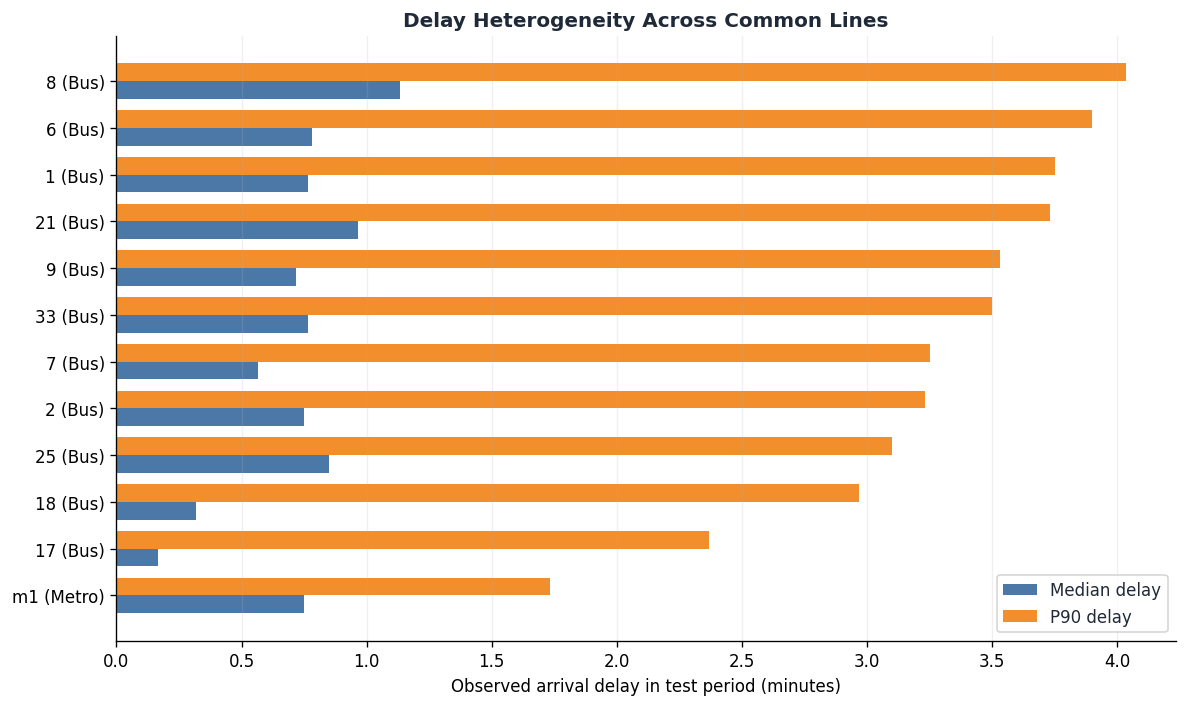

,label,n,median_min,p90_min
11,m1 (Metro),110775,0.75,1.73
5,17 (Bus),135617,0.17,2.37
1,18 (Bus),172174,0.32,2.97
6,25 (Bus),135175,0.85,3.10
3,2 (Bus),140162,0.75,3.23
9,7 (Bus),122284,0.57,3.25
7,33 (Bus),128858,0.77,3.50
10,9 (Bus),110901,0.72,3.53
8,21 (Bus),126138,0.97,3.73
0,1 (Bus),198795,0.77,3.75


In [41]:
# Operational Plot A — Common lines: observed median and p90 delay

line_groups = ["line_text"] + (["transport_clean"] if "transport_clean" in test_pred_df.columns else [])

common_line_pdf = (
    test_pred_df.filter(F.col("line_text").isNotNull())
    .groupBy(*line_groups)
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.5)").alias("median_sec"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.9)").alias("p90_sec")
    )
    .orderBy(F.desc("n")).limit(12).toPandas()
)
common_line_pdf["label"] = common_line_pdf["line_text"].astype(str)
if "transport_clean" in common_line_pdf:
    common_line_pdf["label"] += " (" + common_line_pdf["transport_clean"].astype(str) + ")"
common_line_pdf["median_min"] = common_line_pdf["median_sec"] / 60
common_line_pdf["p90_min"] = common_line_pdf["p90_sec"] / 60
common_line_pdf = common_line_pdf.sort_values("p90_min")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(common_line_pdf)); h = 0.38
ax.barh(y-h/2, common_line_pdf["median_min"], height=h, color="#4C78A8", label="Median delay")
ax.barh(y+h/2, common_line_pdf["p90_min"], height=h, color="#F28E2B", label="P90 delay")
ax.set_yticks(y); ax.set_yticklabels(common_line_pdf["label"])
ax.set_xlabel("Observed arrival delay in test period (minutes)")
ax.set_title("Delay Heterogeneity Across Common Lines", fontweight="bold")
ax.legend(); ax.grid(axis="x", alpha=0.20); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_delay_by_common_line.png", dpi=300, bbox_inches="tight")
plt.show()
display(common_line_pdf[["label", "n", "median_min", "p90_min"]].round(2))

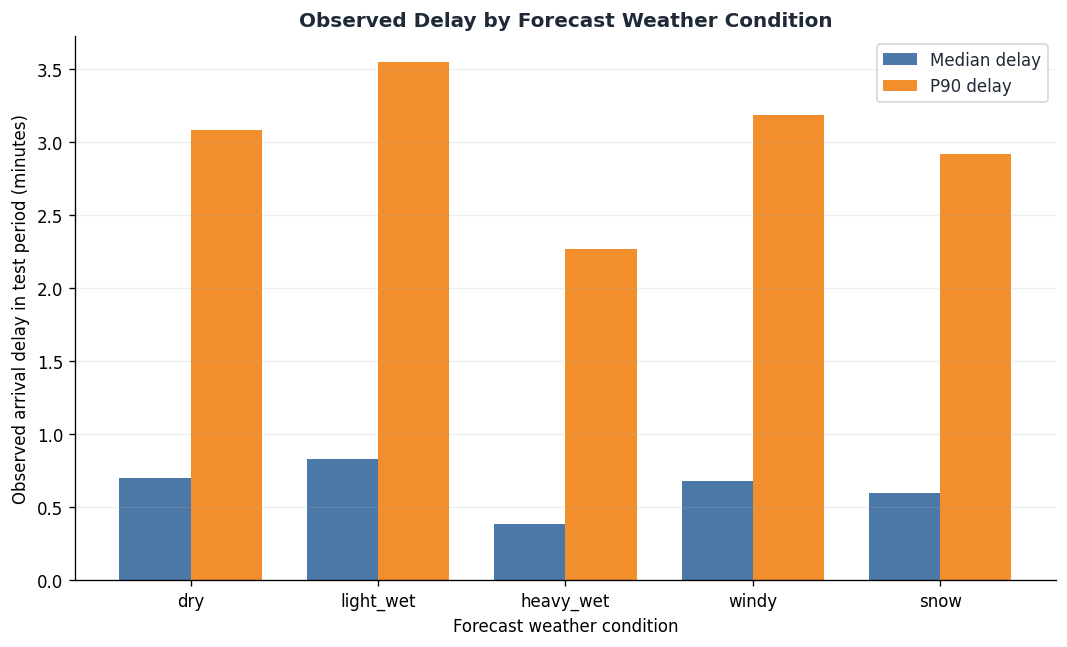

,weather_bucket,n,median_sec,p90_sec,median_min,p90_min
1,dry,2384318,42,185,0.70,3.08
0,light_wet,316990,50,213,0.83,3.55
4,heavy_wet,9027,23,136,0.38,2.27
2,windy,77332,41,191,0.68,3.18
3,snow,29974,36,175,0.60,2.92


In [42]:
# Operational Plot B — Observed delay by forecast weather bucket

weather_cols = ["snowfall_fcst_d1", "precipitation_fcst_d1", "wind_gusts_10m_fcst_d1"]
missing_weather = [c for c in weather_cols if c not in test_pred_df.columns]
if missing_weather:
    raise ValueError(f"Weather columns unavailable: {missing_weather}")

weather_df = test_pred_df.withColumn(
    "weather_bucket",
    F.when(F.col("snowfall_fcst_d1") > 0, "snow")
     .when(F.col("precipitation_fcst_d1") >= 2.0, "heavy_wet")
     .when(F.col("precipitation_fcst_d1") > 0.1, "light_wet")
     .when(F.col("wind_gusts_10m_fcst_d1") > 50, "windy")
     .otherwise("dry")
)
weather_order = ["dry", "light_wet", "heavy_wet", "windy", "snow"]
weather_pdf = (
    weather_df.groupBy("weather_bucket")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.5)").alias("median_sec"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.9)").alias("p90_sec")
    ).toPandas()
)
weather_pdf["weather_bucket"] = pd.Categorical(weather_pdf["weather_bucket"], weather_order, ordered=True)
weather_pdf = weather_pdf.sort_values("weather_bucket")
weather_pdf["median_min"] = weather_pdf["median_sec"] / 60
weather_pdf["p90_min"] = weather_pdf["p90_sec"] / 60

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(weather_pdf)); w = 0.38
ax.bar(x-w/2, weather_pdf["median_min"], width=w, color="#4C78A8", label="Median delay")
ax.bar(x+w/2, weather_pdf["p90_min"], width=w, color="#F28E2B", label="P90 delay")
ax.set_xticks(x); ax.set_xticklabels(weather_pdf["weather_bucket"].astype(str))
ax.set_ylabel("Observed arrival delay in test period (minutes)")
ax.set_xlabel("Forecast weather condition")
ax.set_title("Observed Delay by Forecast Weather Condition", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.20); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_delay_by_forecast_weather.png", dpi=300, bbox_inches="tight")
plt.show()
display(weather_pdf.round(2))

**Interpretation**

> Forecast weather is among the strongest model signals and is available at prediction time. If upper-tail delays differ across forecast weather categories in the test period, this supports using forecast conditions in a risk-sensitive routing context.

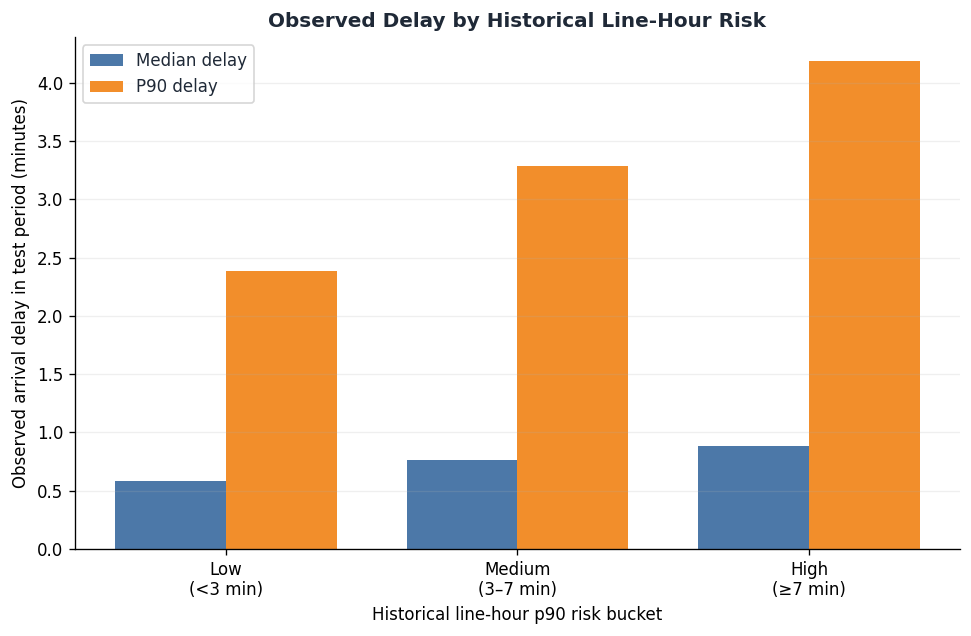

,line_risk_bucket,n,median_sec,p90_sec,median_min,p90_min
0,low,867344,35,143,0.58,2.38
2,medium,1514427,46,197,0.77,3.28
1,high,435870,53,251,0.88,4.18


In [43]:
# Operational Plot C — Historical line-hour p90 bucket vs observed test-period delay

hist_col = "hist_line_hour_p90_delay"
if hist_col not in test_pred_df.columns:
    raise ValueError(f"Missing historical risk feature: {hist_col}")

risk_df = test_pred_df.withColumn(
    "line_risk_bucket",
    F.when(F.col(hist_col) < 180, "low")
     .when(F.col(hist_col) < 420, "medium")
     .otherwise("high")
)
risk_order = ["low", "medium", "high"]
risk_pdf = (
    risk_df.groupBy("line_risk_bucket")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.5)").alias("median_sec"),
        F.expr("percentile_approx(arrival_delay_seconds, 0.9)").alias("p90_sec")
    ).toPandas()
)
risk_pdf["line_risk_bucket"] = pd.Categorical(risk_pdf["line_risk_bucket"], risk_order, ordered=True)
risk_pdf = risk_pdf.sort_values("line_risk_bucket")
risk_pdf["median_min"] = risk_pdf["median_sec"] / 60
risk_pdf["p90_min"] = risk_pdf["p90_sec"] / 60

labels = ["Low\n(<3 min)", "Medium\n(3–7 min)", "High\n(≥7 min)"]
fig, ax = plt.subplots(figsize=(8.2, 5.4))
x = np.arange(len(risk_pdf)); w = 0.38
ax.bar(x-w/2, risk_pdf["median_min"], width=w, color="#4C78A8", label="Median delay")
ax.bar(x+w/2, risk_pdf["p90_min"], width=w, color="#F28E2B", label="P90 delay")
ax.set_xticks(x); ax.set_xticklabels(labels[:len(risk_pdf)])
ax.set_xlabel("Historical line-hour p90 risk bucket")
ax.set_ylabel("Observed arrival delay in test period (minutes)")
ax.set_title("Observed Delay by Historical Line-Hour Risk", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.20); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_delay_by_historical_line_hour_risk.png", dpi=300, bbox_inches="tight")
plt.show()
display(risk_pdf.round(2))

P(delay <= 60 sec) = 0.6200 = 62.0%


,quantile,delay,probability
0,q01,-84.374383,0.01
1,q05,-38.779718,0.05
2,q10,-24.862502,0.10
3,q20,-9.524776,0.20
4,q35,12.256683,0.35
5,q50,34.520976,0.50
6,q65,66.377415,0.65
7,q80,141.174515,0.80
8,q90,273.004571,0.90
9,q95,462.404842,0.95


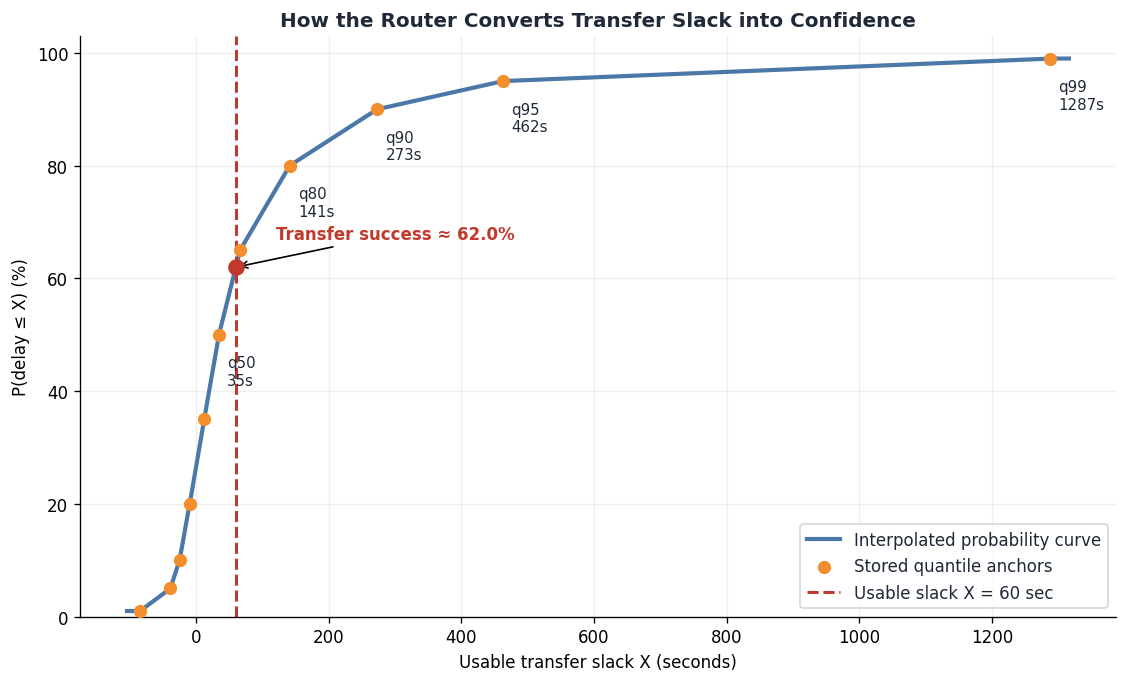

In [51]:
# Plot 5 — Retrieve the actual incoming trip-stop row used by the route-confidence debug

TRIP_ID = "1334.TA.91-m1-j26-1.3.H"
BPUIC = 8591818
DAY = "2026-02-04"
ARRIVAL = "2026-02-04 12:44:00"

row = (
    feb_lookup_df.filter(
        (F.col("trip_id") == TRIP_ID) &
        (F.col("bpuic") == BPUIC) &
        (F.col("operating_day") == F.to_date(F.lit(DAY))) &
        (F.col("scheduled_arrival_ts") == F.to_timestamp(F.lit(ARRIVAL)))
    ).first()
)
if row is None:
    raise ValueError("Actual transfer example not found in February lookup.")
row = row.asDict()

QPOINTS = [
    (0.01, "q01"), (0.05, "q05"), (0.10, "q10"), (0.20, "q20"),
    (0.35, "q35"), (0.50, "q50"), (0.65, "q65"), (0.80, "q80"),
    (0.90, "q90"), (0.95, "q95"), (0.99, "q99")
]

def approximate_probability(row_dict, X):
    points = sorted([(float(row_dict[q]), p) for p, q in QPOINTS], key=lambda z: z[0])
    if X <= points[0][0]:
        return points[0][1]
    if X >= points[-1][0]:
        return points[-1][1]
    for (d0, p0), (d1, p1) in zip(points[:-1], points[1:]):
        if d0 <= X <= d1:
            if d1 == d0:
                return p1
            return p0 + (X - d0) / (d1 - d0) * (p1 - p0)
    return np.nan

X = 60
p_X = approximate_probability(row, X)

anchors = pd.DataFrame({
    "quantile": [q for _, q in QPOINTS],
    "delay": [float(row[q]) for _, q in QPOINTS],
    "probability": [p for p, _ in QPOINTS]
})
xgrid = np.arange(int(anchors["delay"].min()) - 20, int(anchors["delay"].max()) + 31)
curve = pd.DataFrame({"X": xgrid})
curve["p"] = curve["X"].apply(lambda val: approximate_probability(row, val))

print(f"P(delay <= {X} sec) = {p_X:.4f} = {100*p_X:.1f}%")
display(anchors)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.plot(curve["X"], 100 * curve["p"], color="#4C78A8", linewidth=2.5,
        label="Interpolated probability curve")
ax.scatter(anchors["delay"], 100 * anchors["probability"], color="#F28E2B",
           s=48, zorder=3, label="Stored quantile anchors")
for _, r in anchors[anchors["quantile"].isin(["q50", "q80", "q90", "q95", "q99"])].iterrows():
    ax.annotate(f"{r['quantile']}\n{r['delay']:.0f}s",
                (r["delay"], 100*r["probability"]),
                xytext=(5, -30), textcoords="offset points", fontsize=9)
ax.axvline(X, color="#C0392B", linestyle="--", linewidth=1.8,
           label=f"Usable slack X = {X} sec")
ax.scatter([X], [100*p_X], color="#C0392B", s=80, zorder=4)
ax.annotate(f"Transfer success ≈ {100*p_X:.1f}%",
            (X, 100*p_X), xytext=(24, 17), textcoords="offset points",
            arrowprops={"arrowstyle": "->", "lw": 1}, color="#C0392B",
            fontweight="bold")
ax.set_title("How the Router Converts Transfer Slack into Confidence", fontweight="bold")
ax.set_xlabel("Usable transfer slack X (seconds)")
ax.set_ylabel("P(delay ≤ X) (%)")
ax.set_ylim(0, 103)
ax.grid(alpha=0.20)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_transfer_probability_curve.png", dpi=300, bbox_inches="tight")
plt.show()

MIN_GROUP_ROWS = 1000


  L0_simple: 9 groups meet MIN_GROUP_ROWS


  L1_core: 88 groups meet MIN_GROUP_ROWS


  L2_context: 158 groups meet MIN_GROUP_ROWS


  L3_operational: 409 groups meet MIN_GROUP_ROWS


  L4_rich: 932 groups meet MIN_GROUP_ROWS


  L5_ultra_rich: 1,149 groups meet MIN_GROUP_ROWS


  L6_line_specific: 1,396 groups meet MIN_GROUP_ROWS


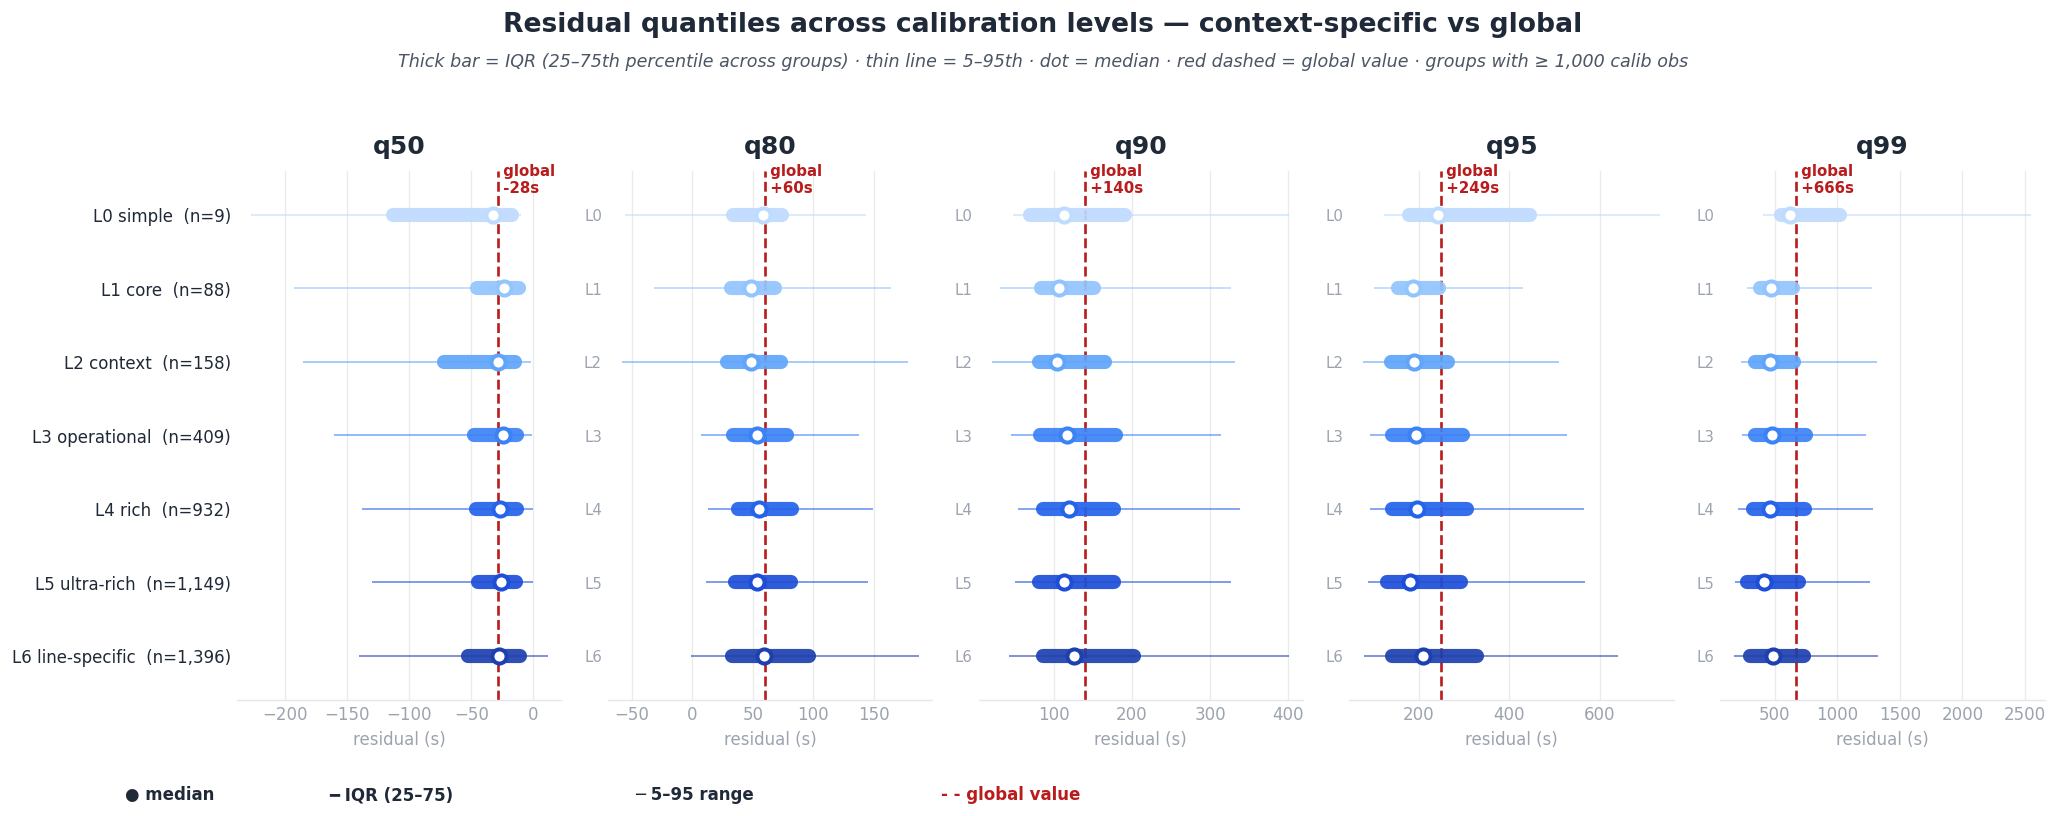

In [81]:
# 1) Global residual quantiles
GLOBAL_PATH = (
    f"{BASE}/calibration_model_data/calibration_artifacts/"
    "global_residual_quantiles.parquet"
)
_global_q_df = spark.read.parquet(GLOBAL_PATH)
global_q = {
    row["quantile"]: float(row["residual_quantile"])
    for row in _global_q_df.collect()
}

# 2) MIN_GROUP_ROWS threshold (from config)
CONFIG_PATH = (
    f"{BASE}/calibration_model_data/calibration_artifacts/"
    "calibration_config.parquet"
)
try:
    _cfg = spark.read.parquet(CONFIG_PATH)
    MIN_GROUP_ROWS = int(_cfg.select("min_group_rows").first()["min_group_rows"])
except Exception:
    MIN_GROUP_ROWS = 500
print(f"MIN_GROUP_ROWS = {MIN_GROUP_ROWS}")

# 3) For each level, load the residual table and pull the quantiles for
#    groups that meet the min-rows threshold.
LEVEL_TABLES_PATH = (
    f"{BASE}/calibration_model_data/calibration_artifacts/"
    "calibration_residual_tables"
)
LEVEL_NAMES = [
    "L0_simple", "L1_core", "L2_context", "L3_operational",
    "L4_rich", "L5_ultra_rich", "L6_line_specific",
]
QUANTILES = ["q50", "q80", "q90", "q95", "q99"]

level_dfs = {}
for lvl in LEVEL_NAMES:
    path = f"{LEVEL_TABLES_PATH}/{lvl}.parquet"
    df = spark.read.parquet(path)
    n_col = f"{lvl}_n_rows"
    sel_cols = [f"{lvl}_residual_{q}" for q in QUANTILES]
    missing = [c for c in [n_col] + sel_cols if c not in df.columns]
    if missing:
        print(f"  ⚠️  {lvl}: missing columns {missing} — skipping")
        level_dfs[lvl] = None
        continue
    pdf = (
        df.filter(F.col(n_col) >= MIN_GROUP_ROWS)
          .select(*sel_cols)
          .toPandas()
    )
    pdf.columns = QUANTILES
    level_dfs[lvl] = pdf
    print(f"  {lvl}: {len(pdf):,} groups meet MIN_GROUP_ROWS")


# 4) Render — horizontal range plot per level (median + IQR + 90% range)

INK="#1F2937"; SOFT="#4B5563"; MUTED="#9CA3AF"
ACCENT="#0F766E"; WARN="#D97706"; HOT="#B91C1C"; RULE="#E5E7EB"
plt.rcParams.update({"font.family":"DejaVu Sans","text.color":INK,
                     "axes.facecolor":"white","figure.facecolor":"white"})

LEVEL_COLORS = {
    "L0_simple":        "#BFDBFE",
    "L1_core":          "#93C5FD",
    "L2_context":       "#60A5FA",
    "L3_operational":   "#3B82F6",
    "L4_rich":          "#2563EB",
    "L5_ultra_rich":    "#1D4ED8",
    "L6_line_specific": "#1E40AF",
}
LEVEL_SHORT = {
    "L0_simple":"L0 simple","L1_core":"L1 core","L2_context":"L2 context",
    "L3_operational":"L3 operational","L4_rich":"L4 rich",
    "L5_ultra_rich":"L5 ultra-rich","L6_line_specific":"L6 line-specific",
}

# Per (level, quantile) compute median, IQR (25-75), and 90% range (5-95)
stats = {}  # stats[lvl][q] = (med, q25, q75, q05, q95, n)
for lvl in LEVEL_NAMES:
    pdf = level_dfs.get(lvl)
    if pdf is None or len(pdf) == 0:
        stats[lvl] = None
        continue
    stats[lvl] = {}
    for q in QUANTILES:
        vals = pdf[q].dropna().values
        if len(vals) == 0:
            stats[lvl][q] = None
        else:
            stats[lvl][q] = {
                "median": float(np.median(vals)),
                "q25": float(np.percentile(vals, 25)),
                "q75": float(np.percentile(vals, 75)),
                "q05": float(np.percentile(vals, 5)),
                "q95": float(np.percentile(vals, 95)),
                "n": len(vals),
            }

fig, axes = plt.subplots(1, 5, figsize=(17, 6.8), facecolor="white", sharey=False)

for i, q in enumerate(QUANTILES):
    ax = axes[i]

    # Collect data for this quantile
    rows = []
    for lvl in LEVEL_NAMES:
        s = stats.get(lvl)
        if s is None or s.get(q) is None:
            continue
        rec = s[q]
        rec["lvl"] = lvl
        rows.append(rec)

    if not rows:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                ha="center", va="center", color=MUTED)
        ax.set_title(q, fontsize=14, fontweight="bold")
        continue

    n_levels = len(rows)
    y_positions = np.arange(n_levels)[::-1]  # L0 at top, L6 at bottom

    for y_pos, rec in zip(y_positions, rows):
        color = LEVEL_COLORS[rec["lvl"]]
        # 5-95 percentile range (thin line)
        ax.plot([rec["q05"], rec["q95"]], [y_pos, y_pos],
                color=color, linewidth=1.2, alpha=0.55, zorder=2)
        # IQR (thick bar)
        ax.plot([rec["q25"], rec["q75"]], [y_pos, y_pos],
                color=color, linewidth=8.5, solid_capstyle="round",
                alpha=0.92, zorder=3)
        # Median dot (white edge for contrast)
        ax.scatter([rec["median"]], [y_pos],
                   color="white", s=72, zorder=5,
                   edgecolor=color, linewidth=2.4)

    # Global value: vertical dashed red line
    g_val = global_q.get(q, None)
    if g_val is not None:
        ax.axvline(g_val, color=HOT, linestyle="--", linewidth=1.6, zorder=1)
        ax.text(g_val, n_levels - 0.3,
                f" global\n +{g_val:.0f}s" if g_val >= 0 else f" global\n {g_val:.0f}s",
                color=HOT, fontsize=9, fontweight="bold",
                ha="left", va="top")

    # Y-axis: show level labels on the leftmost subplot only,
    # short labels (L0..L6) on the others so the bars stay aligned visually
    ax.set_yticks(y_positions)
    if i == 0:
        ax.set_yticklabels(
            [f"{LEVEL_SHORT[r['lvl']]}  (n={r['n']:,})" for r in rows],
            fontsize=10, color=INK,
        )
    else:
        ax.set_yticklabels(
            [r["lvl"].split("_")[0] for r in rows],
            fontsize=9, color=MUTED,
        )

    ax.set_ylim(-0.6, n_levels - 0.4)
    ax.set_title(q, fontsize=15, fontweight="bold", color=INK, pad=10)
    ax.set_xlabel("residual (s)", color=MUTED, fontsize=10)
    ax.tick_params(axis="x", colors=MUTED, length=0, labelsize=10)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", alpha=0.25, zorder=0)
    for sp in ["top","right","left"]:
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color(RULE)

# Headline + subtitle
fig.suptitle(
    "Residual quantiles across calibration levels — context-specific vs global",
    fontsize=16, fontweight="bold", color=INK, y=0.985,
)
fig.text(0.5, 0.935,
         f"Thick bar = IQR (25–75th percentile across groups) · thin line = 5–95th · dot = median · "
         f"red dashed = global value · groups with ≥ {MIN_GROUP_ROWS:,} calib obs",
         fontsize=10.5, color=SOFT, ha="center", va="top", style="italic")

# Inline legend showing what each glyph means
legend_y = 0.025
fig.text(0.05, legend_y, "● median", color=INK, fontsize=10, fontweight="bold",
         ha="left", va="center")
fig.text(0.15, legend_y, "━ IQR (25–75)", color=INK, fontsize=10, fontweight="bold",
         ha="left", va="center")
fig.text(0.30, legend_y, "─ 5–95 range", color=INK, fontsize=10, fontweight="bold",
         ha="left", va="center")
fig.text(0.45, legend_y, "- - global value", color=HOT, fontsize=10, fontweight="bold",
         ha="left", va="center")

plt.tight_layout(rect=[0, 0.06, 1, 0.91])
plt.subplots_adjust(left=0.105) 
fig.savefig(FIGURE_DIR / "section2c_residual_levels_comparison.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


In [ ]:
from scipy.stats import norm, skewnorm

Q_LEVELS = [
    (0.01, "q01"), (0.05, "q05"), (0.10, "q10"), (0.20, "q20"),
    (0.35, "q35"), (0.50, "q50"), (0.65, "q65"), (0.80, "q80"),
    (0.90, "q90"), (0.95, "q95"), (0.99, "q99")
]
missing = [q for _, q in Q_LEVELS if q not in test_quantile_df.columns]
if LABEL_COL not in test_quantile_df.columns or missing:
    raise ValueError(f"Missing coverage columns: label={LABEL_COL not in test_quantile_df.columns}, q={missing}")

# --- Calibrated empirical coverage (current pipeline output) ---
coverage_row = test_quantile_df.select(*[
    F.avg((F.col(LABEL_COL) <= F.col(q)).cast("double")).alias(q)
    for _, q in Q_LEVELS
]).first().asDict()

coverage_pdf = pd.DataFrame([
    {"quantile": q, "target": level, "empirical": float(coverage_row[q])}
    for level, q in Q_LEVELS
])
coverage_pdf["error_pp"] = 100 * (coverage_pdf["empirical"] - coverage_pdf["target"])

# Quantile monotonicity check
qcols = [q for _, q in Q_LEVELS]
bad = None
for low, high in zip(qcols[:-1], qcols[1:]):
    violation = F.col(low) > F.col(high)
    bad = violation if bad is None else (bad | violation)
monotonicity = test_quantile_df.select(
    F.count("*").alias("n_rows"),
    F.sum(bad.cast("int")).alias("n_violations"),
).withColumn("pct_violations", 100 * F.col("n_violations") / F.col("n_rows"))
monotonicity.show(truncate=False)

# --- Load calib residuals for fitting parametric baselines ---
CALIB_PRED_PATH = (
    f"{BASE}/calibration_model_data/evaluation_outputs/"
    "eval_calib_predictions_full.parquet"
)
TEST_PRED_PATH = (
    f"{BASE}/calibration_model_data/evaluation_outputs/"
    "eval_test_predictions_full.parquet"
)
GLOBAL_Q_PATH = (
    f"{BASE}/calibration_model_data/calibration_artifacts/"
    "global_residual_quantiles.parquet"
)

calib_pred_for_fit = spark.read.parquet(CALIB_PRED_PATH)

# Pull calib residuals to pandas — sample if huge to fit skew-normal efficiently
SAMPLE_FOR_SKEW = 1_000_000  # fitting skewnorm on full data is slow; sample for shape estimation
calib_sample = (
    calib_pred_for_fit
    .withColumn("residual", F.col(LABEL_COL) - F.col("pred_delay"))
    .select("residual")
    .sample(fraction=min(1.0, SAMPLE_FOR_SKEW / calib_pred_for_fit.count()),
            seed=42)
    .toPandas()
)
calib_residuals = calib_sample["residual"].dropna().values
print(f"Calib residuals sampled for parametric fit: n = {len(calib_residuals):,}")

# Gaussian fit
mu_residual    = float(np.mean(calib_residuals))
sigma_residual = float(np.std(calib_residuals))
print(f"Gaussian fit    : μ = {mu_residual:+.1f}s, σ = {sigma_residual:.1f}s")

# Skew-Normal fit
skew_a, skew_loc, skew_scale = skewnorm.fit(calib_residuals)
print(f"Skew-Normal fit : α = {skew_a:+.2f}, loc = {skew_loc:+.1f}s, scale = {skew_scale:.1f}s")

# Global residual quantiles (from the calibration artifact)
_gq_df = spark.read.parquet(GLOBAL_Q_PATH)
global_residual_q = {
    row["quantile"]: float(row["residual_quantile"])
    for row in _gq_df.collect()
}

# --- Compute baseline coverage on the TEST set in a single Spark pass ---
test_pred = spark.read.parquet(TEST_PRED_PATH)

baseline_exprs = []
for target, qname in Q_LEVELS:
    # Gaussian
    gauss_thr = F.col("pred_delay") + F.lit(mu_residual + norm.ppf(target) * sigma_residual)
    baseline_exprs.append(
        F.avg((F.col(LABEL_COL) <= gauss_thr).cast("double")).alias(f"gauss_{qname}")
    )
    # Skew-Normal
    skew_thr = F.col("pred_delay") + F.lit(float(
        skewnorm.ppf(target, skew_a, skew_loc, skew_scale)
    ))
    baseline_exprs.append(
        F.avg((F.col(LABEL_COL) <= skew_thr).cast("double")).alias(f"skew_{qname}")
    )
    # Global-conformal (no context-specific backoff)
    g_thr = F.col("pred_delay") + F.lit(global_residual_q[qname])
    baseline_exprs.append(
        F.avg((F.col(LABEL_COL) <= g_thr).cast("double")).alias(f"global_{qname}")
    )

baselines_row = test_pred.select(*baseline_exprs).first().asDict()

# Merge everything into one comparison frame
rows = []
for target, qname in Q_LEVELS:
    rows.append({
        "quantile": qname,
        "target": target,
        "empirical":          float(coverage_row[qname]),
        "naive_empirical":    float(baselines_row[f"gauss_{qname}"]),     # keep this name for back-compat
        "skew_empirical":     float(baselines_row[f"skew_{qname}"]),
        "global_empirical":   float(baselines_row[f"global_{qname}"]),
    })

coverage_compare_pdf = pd.DataFrame(rows)
coverage_compare_pdf["error_pp"]        = 100 * (coverage_compare_pdf["empirical"]        - coverage_compare_pdf["target"])
coverage_compare_pdf["naive_error_pp"]  = 100 * (coverage_compare_pdf["naive_empirical"]  - coverage_compare_pdf["target"])
coverage_compare_pdf["skew_error_pp"]   = 100 * (coverage_compare_pdf["skew_empirical"]   - coverage_compare_pdf["target"])
coverage_compare_pdf["global_error_pp"] = 100 * (coverage_compare_pdf["global_empirical"] - coverage_compare_pdf["target"])

# Summary MAEs
mae_calib  = coverage_compare_pdf["error_pp"].abs().mean()
mae_gauss  = coverage_compare_pdf["naive_error_pp"].abs().mean()
mae_skew   = coverage_compare_pdf["skew_error_pp"].abs().mean()
mae_global = coverage_compare_pdf["global_error_pp"].abs().mean()

print()
print(f"MAE — Calibrated (full backoff)  = {mae_calib:.3f} pp")
print(f"MAE — Global-conformal (no backoff) = {mae_global:.3f} pp")
print(f"MAE — Skew-Normal baseline       = {mae_skew:.3f} pp")
print(f"MAE — Gaussian baseline          = {mae_gauss:.3f} pp")
display(coverage_compare_pdf.round(4))


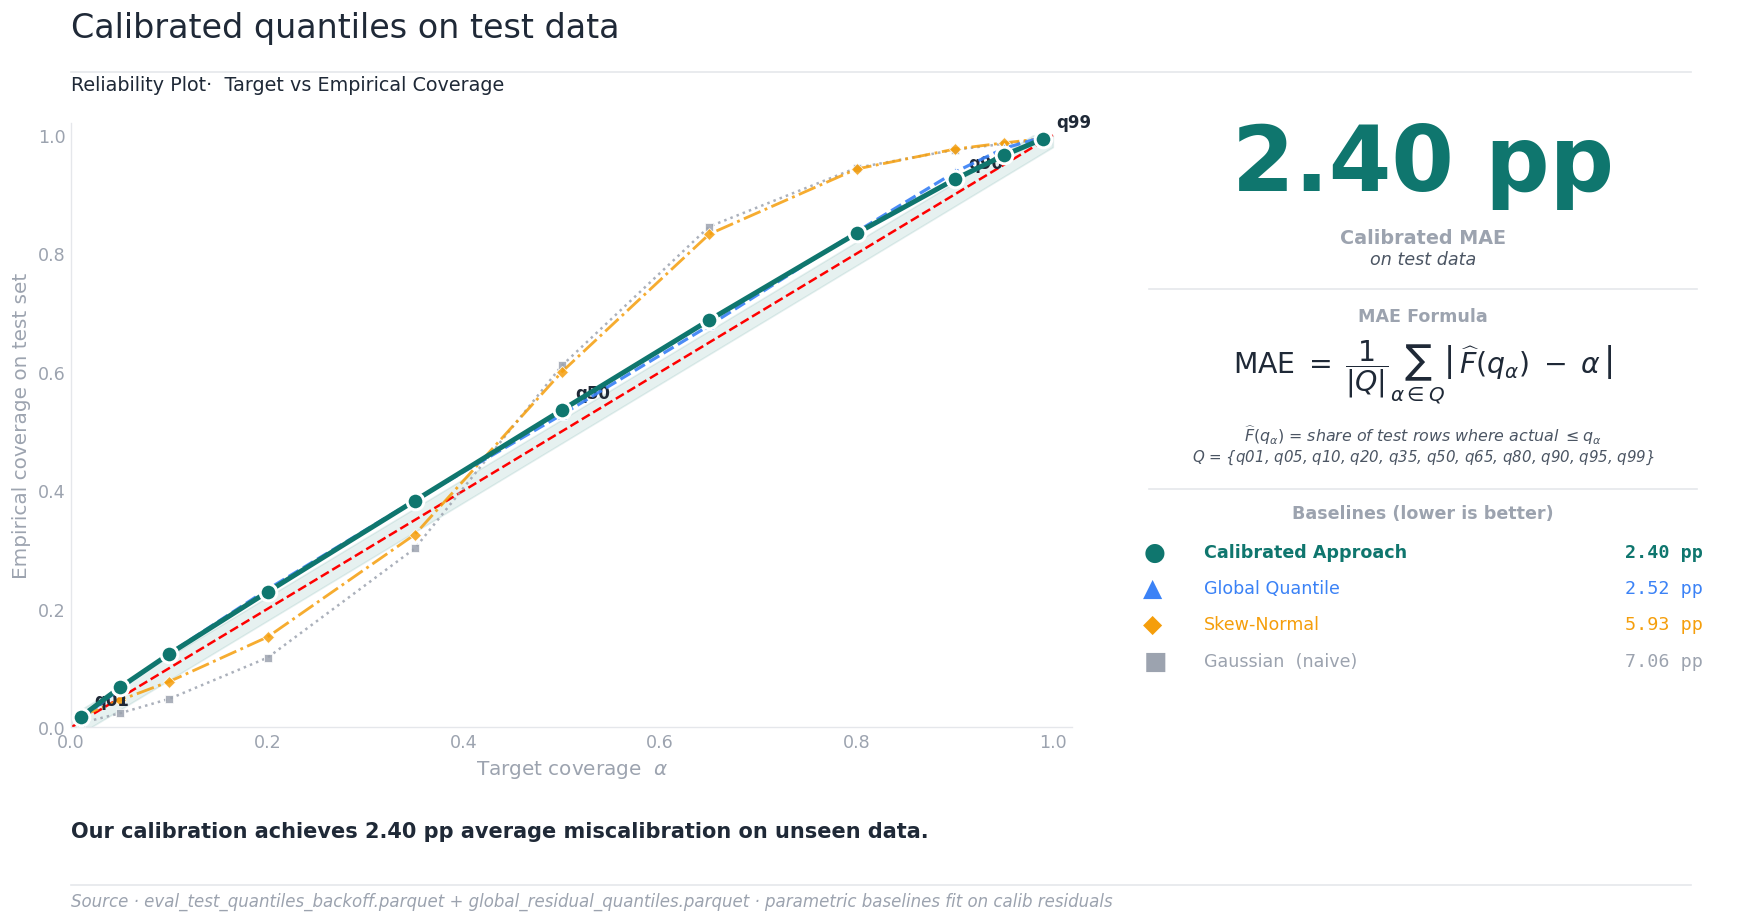

In [76]:
INK="#1F2937"; SOFT="#4B5563"; MUTED="#9CA3AF"
ACCENT="#0F766E"; WARN="#D97706"; HOT="#B91C1C"; RULE="#E5E7EB"
GAUSS_C  = "#9CA3AF"
SKEW_C   = "#F59E0B"
GLOBAL_C = "#3B82F6"
plt.rcParams.update({"font.family":"DejaVu Sans","text.color":INK,
                     "axes.facecolor":"white","figure.facecolor":"white"})

cov = coverage_compare_pdf.copy().sort_values("target").reset_index(drop=True)
cov["abs_err_pp"]        = cov["error_pp"].abs()
cov["naive_abs_err_pp"]  = cov["naive_error_pp"].abs()
cov["skew_abs_err_pp"]   = cov["skew_error_pp"].abs()
cov["global_abs_err_pp"] = cov["global_error_pp"].abs()

mae_pp     = cov["abs_err_pp"].mean()
naive_mae  = cov["naive_abs_err_pp"].mean()
skew_mae   = cov["skew_abs_err_pp"].mean()
global_mae = cov["global_abs_err_pp"].mean()

fig = plt.figure(figsize=(15, 8.5), facecolor="white")

fig.text(0.05, 0.902,
         "Calibrated quantiles on test data",
         fontsize=20, color=INK, ha="left", va="top")


fig.add_artist(plt.Line2D([0.05, 0.95], [0.842, 0.842],
                          color=RULE, linewidth=1, transform=fig.transFigure))

gs = fig.add_gridspec(1, 13, left=0.05, right=0.97, bottom=0.20, top=0.792,
                      wspace=0.55)

ax = fig.add_subplot(gs[0, 0:8])
ax.set_title("Reliability Plot·  Target vs Empirical Coverage",
             loc="left", fontsize=11.5, color=INK, pad=20)

xs = np.linspace(0, 1, 100)
ax.fill_between(xs, np.clip(xs - 0.02, 0, 1), np.clip(xs + 0.02, 0, 1),
                color=ACCENT, alpha=0.10, zorder=1)

# Diagonal (perfect calibration)
ax.plot([0,1], [0,1], color="red", linestyle="--", linewidth=1.5, zorder=2)

ax.plot(cov["target"], cov["naive_empirical"],
        color=GAUSS_C, linewidth=1.5, linestyle=":",
        marker="s", markersize=5, markeredgecolor="white", markeredgewidth=0.5,
        zorder=3, alpha=0.85)
ax.plot(cov["target"], cov["skew_empirical"],
        color=SKEW_C, linewidth=1.7, linestyle="-.",
        marker="D", markersize=5, markeredgecolor="white", markeredgewidth=0.5,
        zorder=3, alpha=0.85)
ax.plot(cov["target"], cov["global_empirical"],
        color=GLOBAL_C, linewidth=1.9, linestyle="--",
        marker="^", markersize=6, markeredgecolor="white", markeredgewidth=0.6,
        zorder=4, alpha=0.92)
ax.plot(cov["target"], cov["empirical"], color=ACCENT, linewidth=3.0,
        marker="o", markersize=10, markeredgecolor="white",
        markeredgewidth=1.8, zorder=5)

for r in cov.itertuples():
    if r.quantile in ["q01", "q50", "q90", "q99"]:
        ax.annotate(r.quantile, (r.target, r.empirical),
                    xytext=(8, 7), textcoords="offset points",
                    fontsize=10, color=INK, fontweight="bold")

ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_xlabel(r"Target coverage  $\alpha$", color=MUTED, fontsize=12)
ax.set_ylabel("Empirical coverage on test set", color=MUTED, fontsize=12)
ax.tick_params(axis="both", colors=MUTED, length=0, labelsize=10.5)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.spines["left"].set_color(RULE); ax.spines["bottom"].set_color(RULE)

ax_kpi = fig.add_subplot(gs[0, 8:13])
ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
for sp in ax_kpi.spines.values(): sp.set_visible(False)

ax_kpi.text(0.5, 0.93, f"{mae_pp:.2f} pp",
            fontsize=54, fontweight="bold", color=ACCENT,
            ha="center", va="center")
ax_kpi.text(0.5, 0.81, "Calibrated MAE",
            fontsize=11.5, color=MUTED, ha="center", va="center",
            fontweight="bold")
ax_kpi.text(0.5, 0.775, "on test data",
            fontsize=10.5, color=SOFT, ha="center", va="center", style="italic")

ax_kpi.plot([0.05, 0.95], [0.725, 0.725], color=RULE, linewidth=1)

ax_kpi.text(0.5, 0.68, "MAE Formula",
            fontsize=10.5, color=MUTED, ha="center", va="center",
            fontweight="bold")
ax_kpi.text(0.5, 0.59,
            r"$\mathrm{MAE} \;=\; \dfrac{1}{|Q|} \sum_{\alpha \in Q} \left|\, \widehat{F}(q_\alpha) \;-\; \alpha \,\right|$",
            fontsize=17, color=INK, ha="center", va="center")
ax_kpi.text(0.5, 0.485,
            r"$\widehat{F}(q_\alpha)$ = share of test rows where actual $\leq q_\alpha$",
            fontsize=9.5, color=SOFT, ha="center", va="center", style="italic")
ax_kpi.text(0.5, 0.448,
            r"$Q$ = {q01, q05, q10, q20, q35, q50, q65, q80, q90, q95, q99}",
            fontsize=9, color=SOFT, ha="center", va="center", style="italic")

ax_kpi.plot([0.05, 0.95], [0.395, 0.395], color=RULE, linewidth=1)

ax_kpi.text(0.5, 0.355, "Baselines (lower is better)",
            fontsize=10.5, color=MUTED, ha="center", va="center",
            fontweight="bold")

baselines_list = [
    ("●", "Calibrated Approach", mae_pp,     ACCENT, True),
    ("▲", "Global Quantile",            global_mae, GLOBAL_C, False),
    ("◆", "Skew-Normal",                 skew_mae,   SKEW_C, False),
    ("■", "Gaussian  (naive)",           naive_mae,  GAUSS_C, False),
]
y_start = 0.290
y_step = 0.060
for i, (marker_char, label, val, color, is_hero) in enumerate(baselines_list):
    y = y_start - i * y_step
    weight = "bold" if is_hero else "normal"
    ax_kpi.text(0.04, y, marker_char, color=color, fontsize=15,
                ha="left", va="center", fontweight="bold")
    ax_kpi.text(0.14, y, label, color=color, fontsize=10.5,
                ha="left", va="center", fontweight=weight)
    ax_kpi.text(0.96, y, f"{val:.2f} pp", color=color, fontsize=11,
                ha="right", va="center", fontweight=weight,
                family="monospace")

fig.text(0.05, 0.108,
         f"Our calibration achieves {mae_pp:.2f} pp average miscalibration on unseen data.\n", 
         fontsize=12.5, fontweight="bold", color=INK, ha="left", va="top")

fig.add_artist(plt.Line2D([0.05, 0.95], [0.045, 0.045],
                          color=RULE, linewidth=1, transform=fig.transFigure))
fig.text(0.05, 0.025,
         "Source · eval_test_quantiles_backoff.parquet + global_residual_quantiles.parquet · "
         "parametric baselines fit on calib residuals",
         fontsize=10, color=MUTED, ha="left", style="italic")

fig.savefig(FIGURE_DIR / "03_deck_validation.png",
            dpi=200, bbox_inches=None, facecolor="white")
plt.show()
